<a href="https://colab.research.google.com/github/IvyOfomata/Practical_Data_Science_Project--Home_Equity_Loan-_Default_Prediction/blob/main/Pratical_Data_Science_Project_Home_Equity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loan Default Prediction**

             



**Problem Statement**


A bank's consumer credit department aims to simplify the decision-making process for home equity lines of credit to be accepted. To do this, they will adopt the Equal Credit Opportunity Act's guidelines to establish an empirically derived and statistically sound model for credit scoring. The model will be based on the data obtained via the existing loan underwriting process from recent applicants who have been given credit. The model will be built from predictive modeling techniques, but the model created must be interpretable enough to provide a justification for any adverse behavior (rejections).



**Objective**


Build a classification model to predict clients who are likely to default on their loan and give recommendations to the bank on the important features to consider while approving a loan.

**Data Dictionary**

The Home Equity dataset (HMEQ) contains baseline and loan performance information for recent home equity loans. The target (BAD) is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent. There are 12 input variables registered for each applicant.


● BAD: 1 = Client defaulted on loan, 0 = loan repaid

● LOAN: Amount of loan approved

● MORTDUE: Amount due on the existing mortgage

● VALUE: Current value of the property

● REASON: Reason for the loan request (HomeImp = home improvement, DebtCon= debt
consolidation which means taking out a new loan to pay off other liabilities and consumer debts)

● JOB: The type of job that loan applicant has such as manager, self, etc.

● YOJ: Years at present job

● DEROG: Number of major derogatory reports (which indicates serious delinquency or late payments).

● DELINQ: Number of delinquent credit lines (a line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the day on which the payments were due)

● CLAGE: Age of the oldest credit line in months

● NINQ: Number of recent credit inquiries

● CLNO: Number of existing credit lines

● DEBTINC: Debt-to-income ratio (all monthly debt payments divided by gross monthly income. This number is one of the ways lenders measure a borrower’s ability to manage the monthly payments to repay the money they plan to borrow)

In [1]:
import pandas as pd
import numpy as np
import matplotlib .pyplot as plt
import seaborn as sns

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#Algorithms to use
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics to evaluate the model
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report,recall_score,precision_score, accuracy_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc, f1_score, roc_auc_score

# For tuning the model
from sklearn.model_selection import GridSearchCV


# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#loading the dataset
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/hmeq.csv')

Mounted at /content/drive


In [3]:
print(df.head())
print(df.info())


   BAD  LOAN  MORTDUE     VALUE   REASON     JOB   YOJ  DEROG  DELINQ  \
0    1  1100  25860.0   39025.0  HomeImp   Other  10.5    0.0     0.0   
1    1  1300  70053.0   68400.0  HomeImp   Other   7.0    0.0     2.0   
2    1  1500  13500.0   16700.0  HomeImp   Other   4.0    0.0     0.0   
3    1  1500      NaN       NaN      NaN     NaN   NaN    NaN     NaN   
4    0  1700  97800.0  112000.0  HomeImp  Office   3.0    0.0     0.0   

        CLAGE  NINQ  CLNO  DEBTINC  
0   94.366667   1.0   9.0      NaN  
1  121.833333   0.0  14.0      NaN  
2  149.466667   1.0  10.0      NaN  
3         NaN   NaN   NaN      NaN  
4   93.333333   0.0  14.0      NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4  



*  There are 5960 data. However, many columns have missing data.




In [4]:
#Check for missing values
df.isnull().sum()

,0
BAD,0
LOAN,0
MORTDUE,518
VALUE,112
REASON,252
JOB,279
YOJ,515
DEROG,708
DELINQ,580
CLAGE,308


**Observations**:

*  Among all missing values, Debt to Income Ratio has the highest with over 21% of missing data. Since this is a sensitivity data that contains the most important predictor of loan default, missing value should be treated as a massive risk.

*   Similarly missing values in JOB & REASON raise a high red flag. So rather than using a mode to guess the values, missing data will be captured as unknown
*   DEROG & DELINQ : The missing values here will also be handled specially by creating a separate colunm that tells the ML model that information was not diclosed. Since the majority of the data is 0,  using the standard mean or median code will end up producing the same 0 result.



*   The Target Variable 'BAD" has 0 missing values, this is ideal & requires no cleanup


*  While outliers exist across multiple variables(as seen from the missing data), my outlier analysis will be focused heavily on high- impact, high-missing colunms like DEBTINC.






**Data Processing**

In [5]:
#Filling missing values
#DEBTINC need to be handled specially

df['DEBTINC_was missing'] = df['DEBTINC'].isna().astype(int) # since this is sensitive, mark that it was missing (1 for missing,0 not missing) write this code before a simple median code
df['DEBTINC'] = df['DEBTINC'].fillna(df['DEBTINC'].median())

#filling JOB & REASON with unknown
df['REASON'] = df['REASON'].fillna('Unknown')
df['JOB'] = df['JOB'].fillna('Unknown')

# DEROG & DELINQ need to be handled specially to create an awareness for the model
df['DEROG_was missing'] = df['DEROG'].isna().astype(int)
df['DEROG'] = df['DEROG'].fillna(0)
df['DELINQ_was missing'] = df['DELINQ'].isna().astype(int)
df['DELINQ'] = df['DELINQ'].fillna(0)

# To handle all other missing values with a loop code
missing_cols = ['MORTDUE', 'VALUE', 'YOJ', 'CLAGE', 'NINQ', 'CLNO']
for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())



In [6]:
# to check if missing values have been handled
df.isna().sum()

,0
BAD,0
LOAN,0
MORTDUE,0
VALUE,0
REASON,0
JOB,0
YOJ,0
DEROG,0
DELINQ,0
CLAGE,0


In [7]:
#Check for duplicate
df.duplicated().sum()

np.int64(0)



*   No duplicate




In [8]:
#check for unique values
df.nunique()

,0
BAD,2
LOAN,540
MORTDUE,5054
VALUE,5382
REASON,3
JOB,7
YOJ,99
DEROG,11
DELINQ,14
CLAGE,5314


**Observations:**

 Running the df.unique code served as a quality assurance check to confirm that:

*  JOB had 7 unique categories. A number like 150 would flag for a major text corruption or typo problem that needs fixing before encoding.



* There are 3 unique categories in the REASON variable.


*    No column had a count of 1. A column with 1 is usually not useful for prediction.
*   Missing value indicators(_ was missing) successfully created exactly 2 groups(0 and 1)





**Summary Statistics**

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BAD,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5960.0,73001.041812,42552.726779,2063.000000,48139.000000,65019.000000,88200.250000,399550.000000
VALUE,5960.0,101540.387423,56869.436682,8000.000000,66489.500000,89235.500000,119004.750000,855909.000000
YOJ,5960.0,8.756166,7.259424,0.000000,3.000000,7.000000,12.000000,41.000000
DEROG,5960.0,0.224329,0.798458,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5960.0,0.405705,1.079256,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5960.0,179.440725,83.574697,0.000000,117.371430,173.466667,227.143058,1168.233561
NINQ,5960.0,1.170134,1.653866,0.000000,0.000000,1.000000,2.000000,17.000000
CLNO,5960.0,21.247819,9.951308,0.000000,15.000000,20.000000,26.000000,71.000000


**Observations:**


*   Loan variable span from a minimum of 1,100 to maximum of 89,900 with average loan at $18,607

  

*   YOJ shows a right skewed distribution where half of the applicants have been at the their job for 7yrs while the average sits slightly higher at 8.76yrs





*   From both DEROG & DELINQ variables, it appears vast majority of applicants have clean credit profiles. 75% of all applicants have zero derogatory marks & delinquencies.


*   As expected DEBTINC shows extreme outliers at the tail end of the feature.








**Exploratory Data Analysis(EDA) and Visualization**

**Univariate Analysis for Numerical Variables**

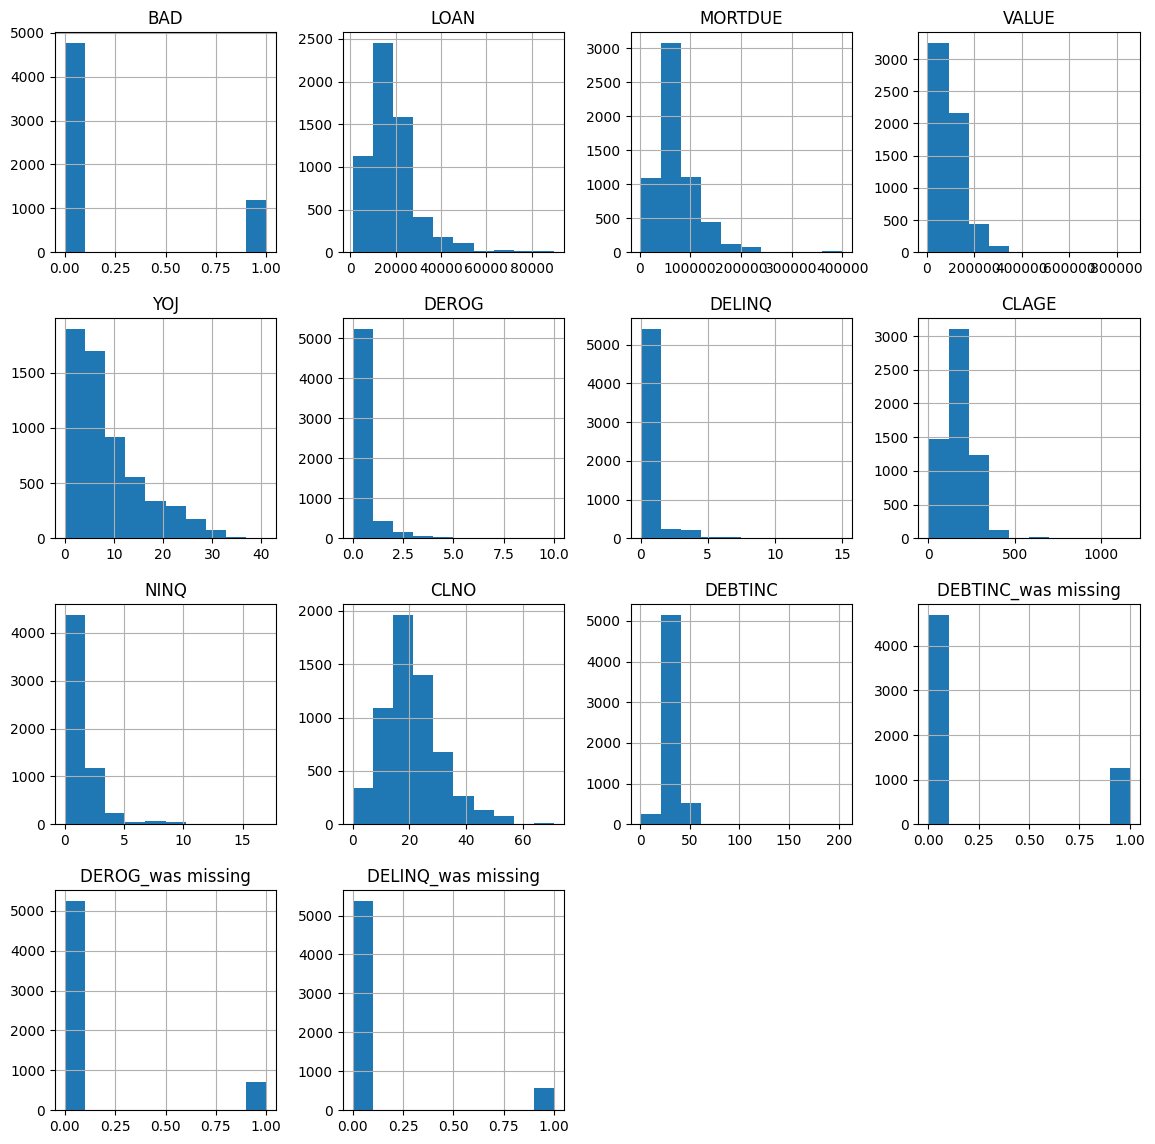

In [10]:
# Creating Histograms
df.hist(figsize=(14, 14))
plt.show()

**Observations**:

*  The data tells us that this bank mostly lends to highly stable, low-risk individuals. The typical applicant has zero delinquencies, zero derogatory remarks, has been at their job for several years, and maintains a highly standard debt-to-income ratio around $34\%$. However, because the distributions are heavily right-skewed, the model will have to contend with a small handful of extreme "high-risk" anomalies on the far-right tails (such as individuals with $15$ active delinquencies or a $203\%$ debt-to-income ratio).

*   Because the data is dominated by hard boundaries (like the wall of zeros in credit infractions) and heavily stretched tails (in property values and loan amounts), Decision Trees, Random Forests, and XGBoost will naturally thrive here. Tree models excel at dealing with skewed data and extreme outliers because they split variables using binary thresholds (e.g., is DELINQ > 0?) rather than assuming a smooth, symmetric bell curve.



**Check the distribution with Outliers for numerical columns**

BAD
Skew : 1.5


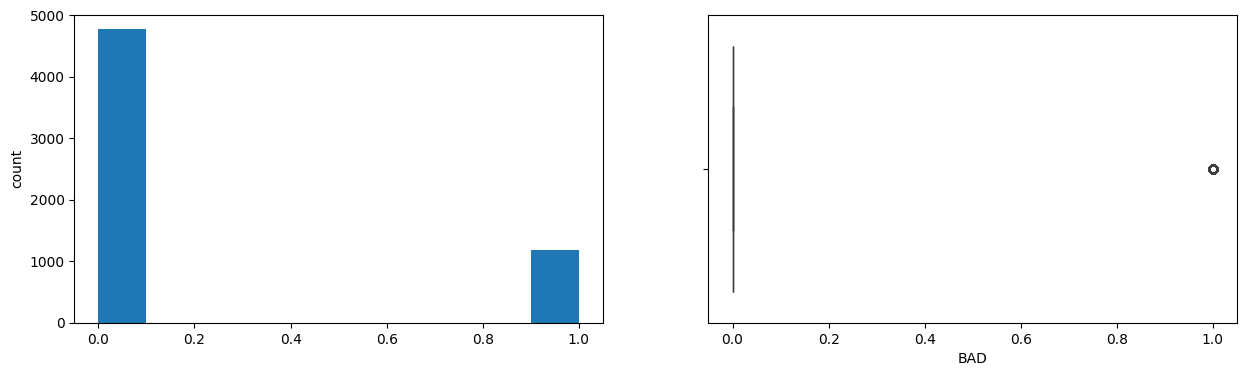

LOAN
Skew : 2.02


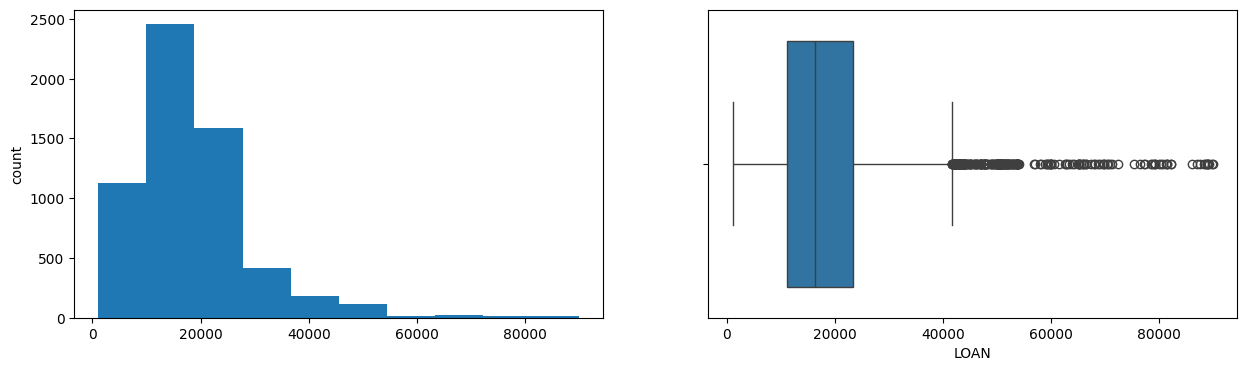

MORTDUE
Skew : 1.94


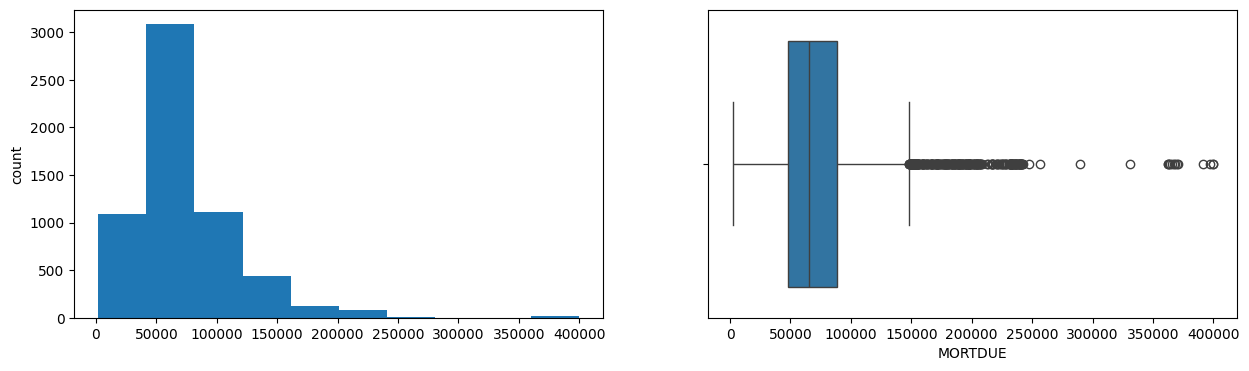

VALUE
Skew : 3.09


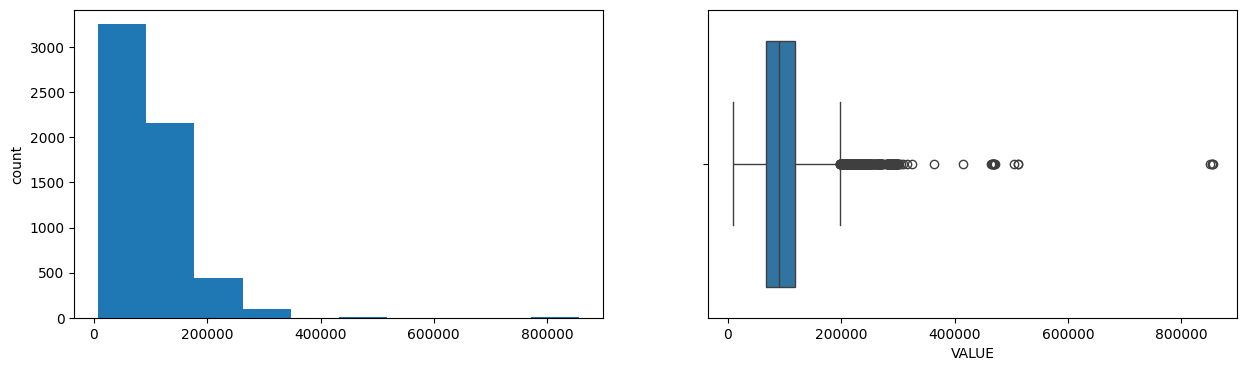

YOJ
Skew : 1.09


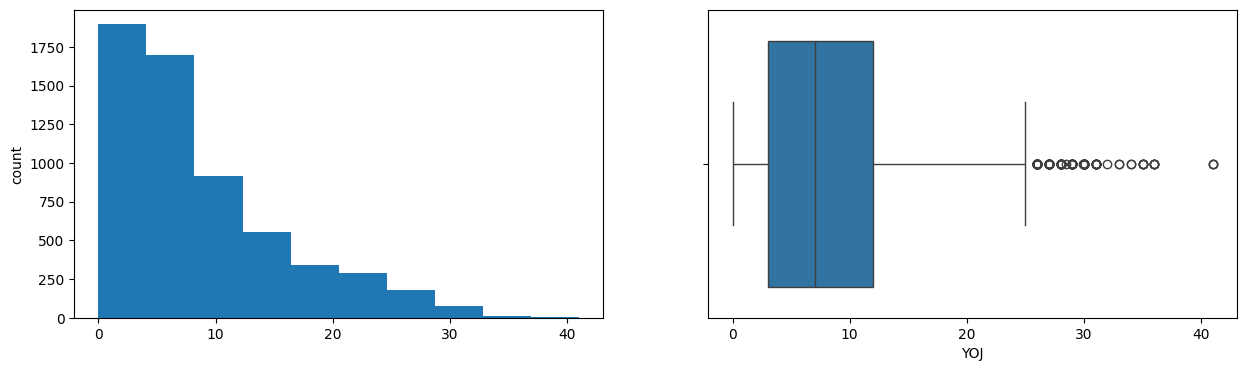

DEROG
Skew : 5.69


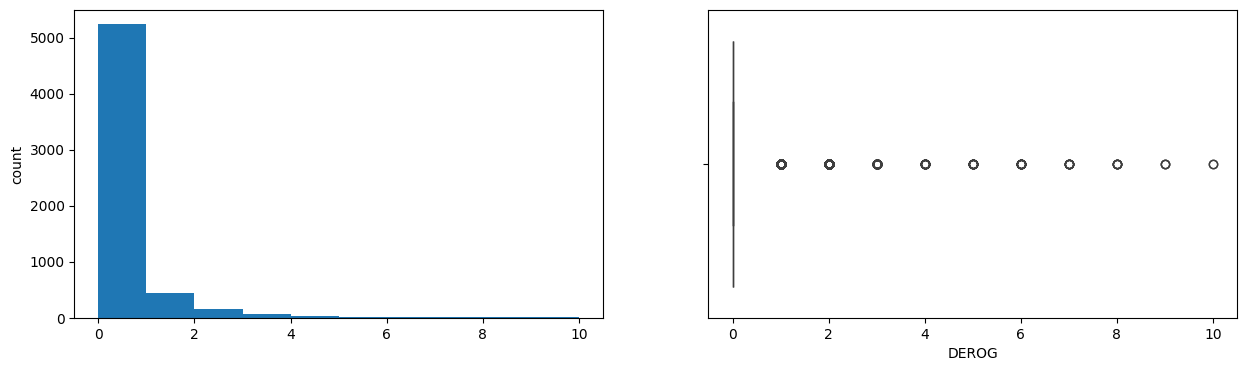

DELINQ
Skew : 4.25


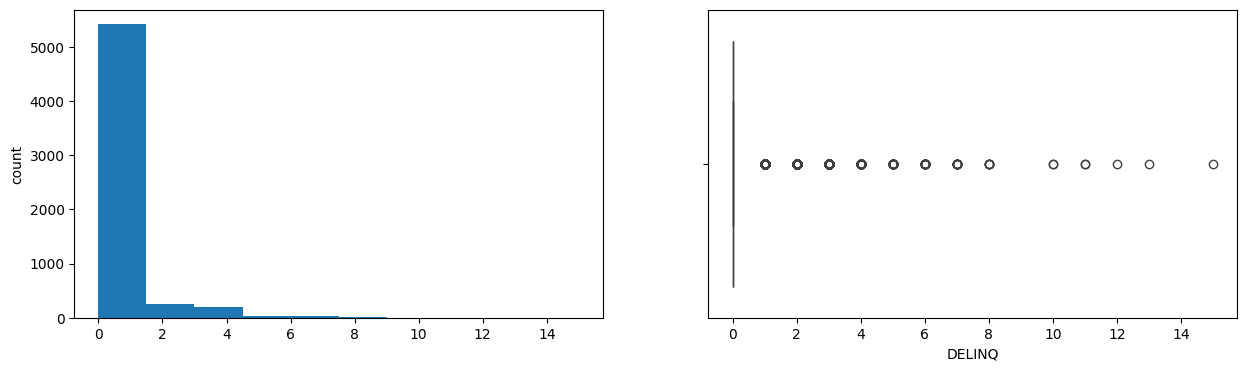

CLAGE
Skew : 1.39


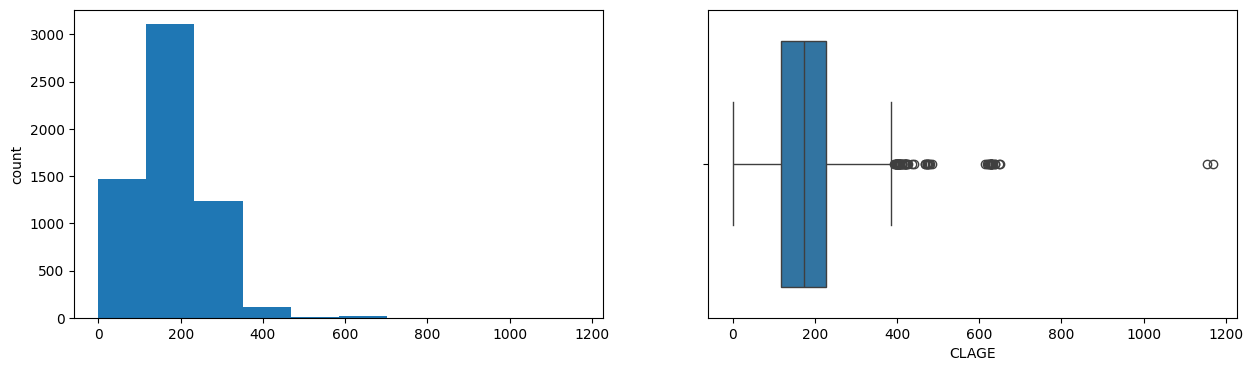

NINQ
Skew : 2.77


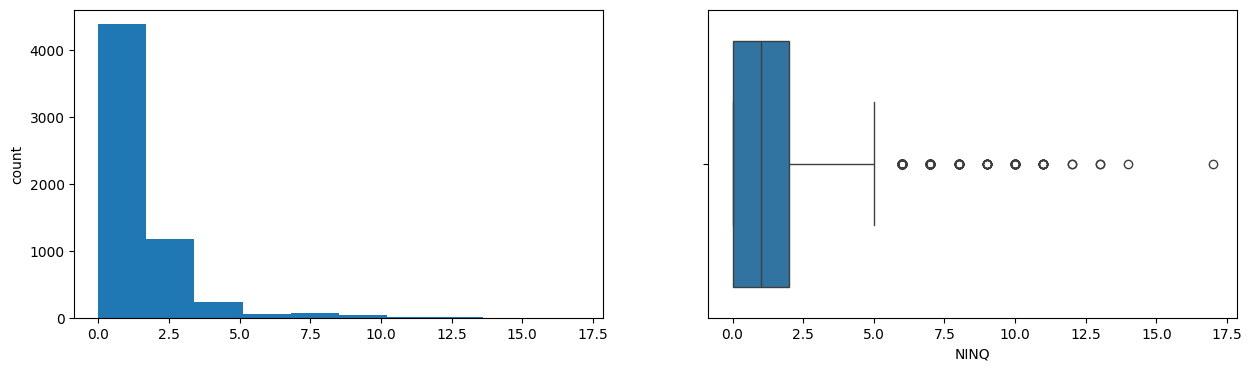

CLNO
Skew : 0.8


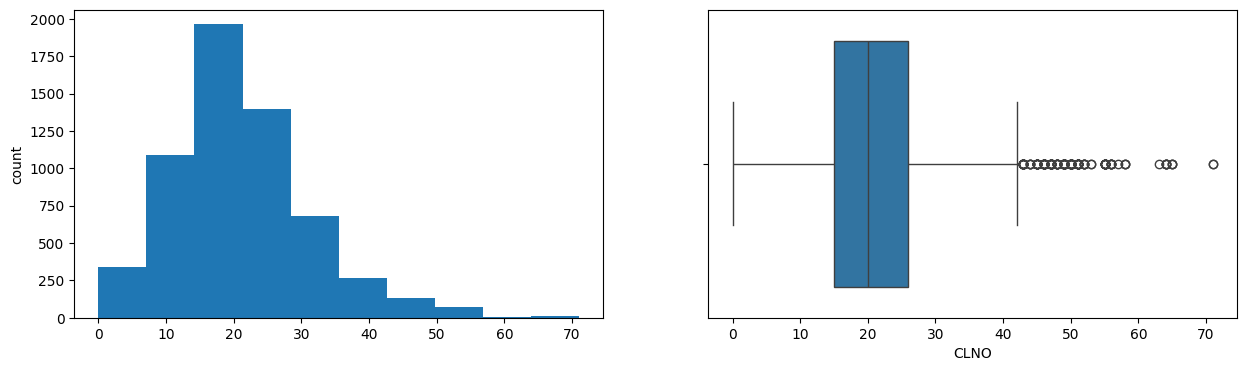

DEBTINC
Skew : 3.11


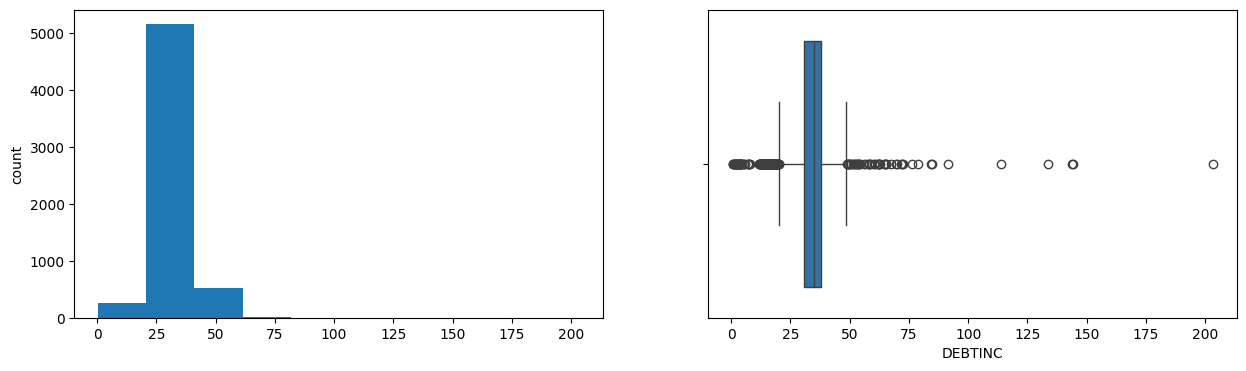

DEBTINC_was missing
Skew : 1.41


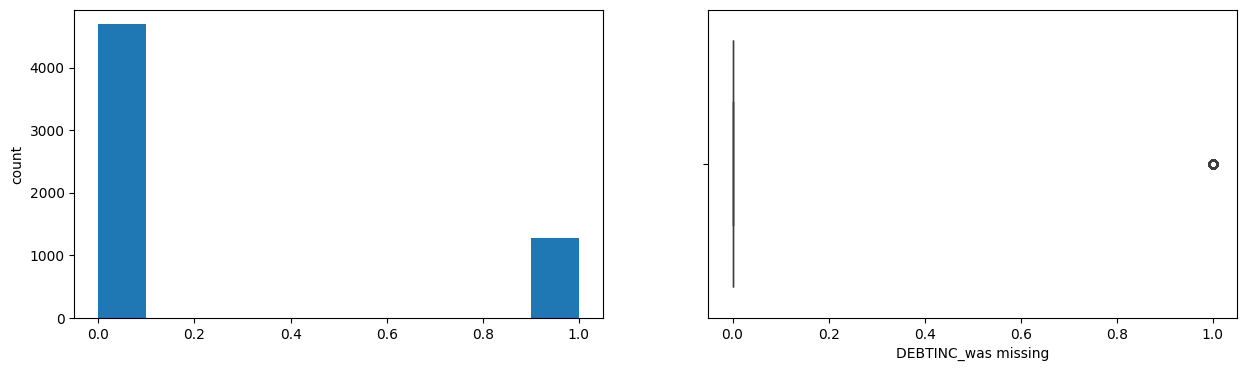

DEROG_was missing
Skew : 2.36


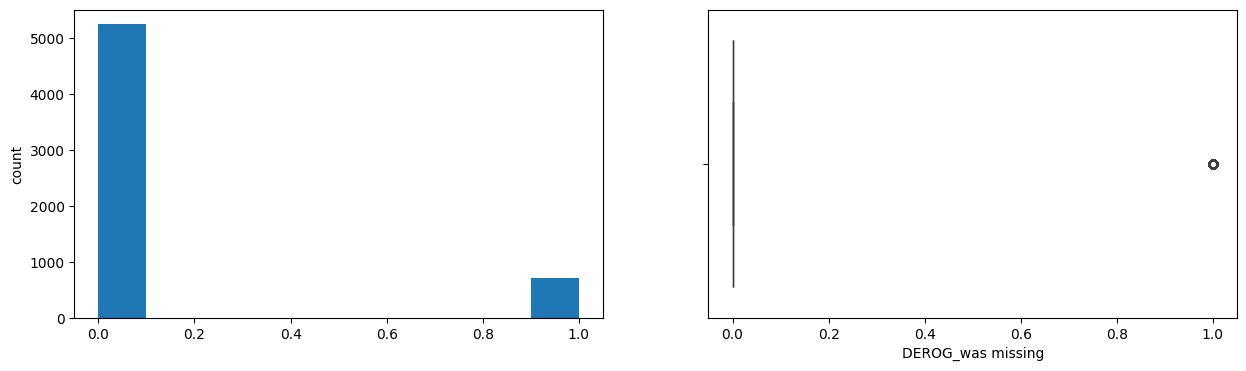

DELINQ_was missing
Skew : 2.72


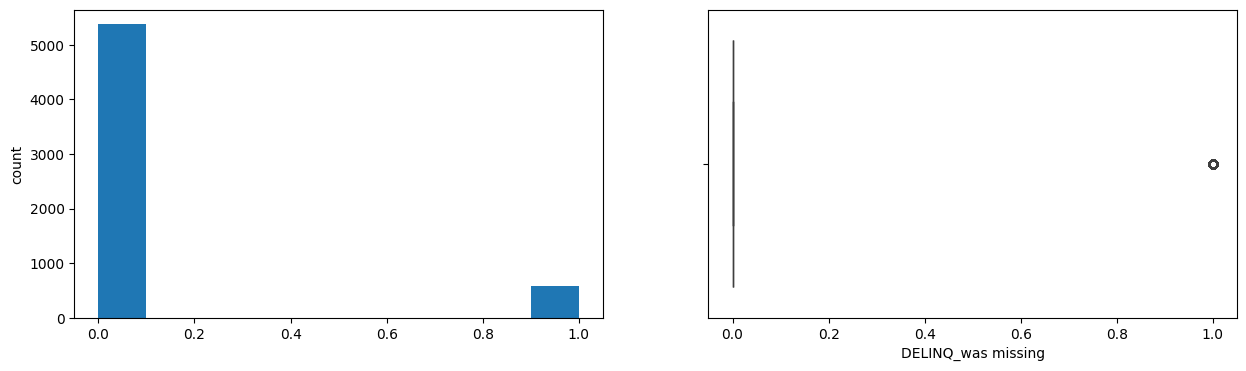

In [11]:
result = df.select_dtypes(include = 'number')

cont_cols = list(result)

for col in cont_cols:

    print(col)

    print('Skew :',round(df[col].skew(),2))

    plt.figure(figsize = (15, 4))

    plt.subplot(1, 2, 1)

    df[col].hist(bins = 10, grid = False)

    plt.ylabel('count')

    plt.subplot(1, 2, 2)

    sns.boxplot(x = df[col])

    plt.show()

**Observations:**

Virtually every continuous numerical variable in the dataset is heavily saturated with outliers. Features like LOAN, MORTDUE, VALUE, YOJ, CLAGE, and NINQ show a heavy dense block of outlier points past the upper whiskers, while DEBTINC has extreme points stretching out on both ends.

**Univariate Analysis for Categorical Variables**

In [12]:
# Separate Numerical & Categorical columns
# Continuous numeric columns that need scaling (averages, dollar amounts, etc.)
num_cols = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'DEROG', 'DELINQ']

#  Categorical text columns that need one-hot encoding
cat_cols = ['REASON', 'JOB']

#  Binary flags that are already 0 or 1 (leave them exactly as they are)
passthrough_cols = ['DEBTINC_was_missing', 'DEROG_was_missing', 'DELINQ_was_missing']

In [13]:
for i in cat_cols:
    print(df[i].value_counts(normalize=True))

    print('*'*40)

REASON
DebtCon    0.659060
HomeImp    0.298658
Unknown    0.042282
Name: proportion, dtype: float64
****************************************
JOB
Other      0.400671
ProfExe    0.214094
Office     0.159060
Mgr        0.128691
Unknown    0.046812
Self       0.032383
Sales      0.018289
Name: proportion, dtype: float64
****************************************


**Obervations:**

*  Debt Consolidation is the main driver; $65.91\%$ of applicants are borrowing to consolidate existing debt, while only $29.87\%$ are using the money for home improvements.
* Over $50\%$ of applicants work in stable corporate roles (Executives, Office staff, and Managers), creating a very reliable income base for the bank. This shows why the credit profiles(DELINQ & DEROG) are clean


*   The "Unknown" category accounts for a tiny $4.23\%$ of the REASON column and just $4.68\%$ of the JOB column. Having well under $5\%$ of the data missing here means that the text categories are incredibly reliable.






**Bivariate Analysis**

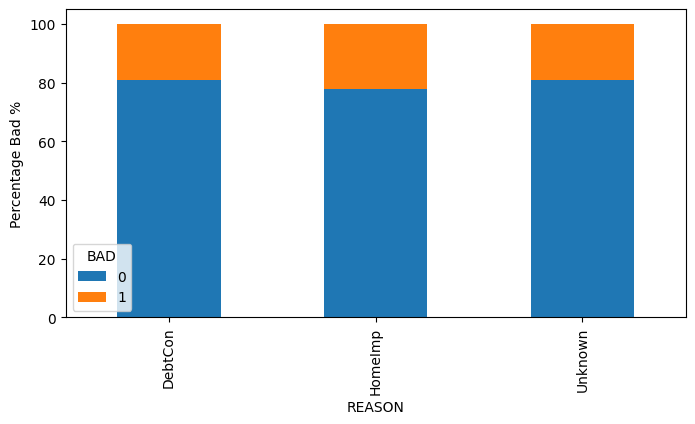

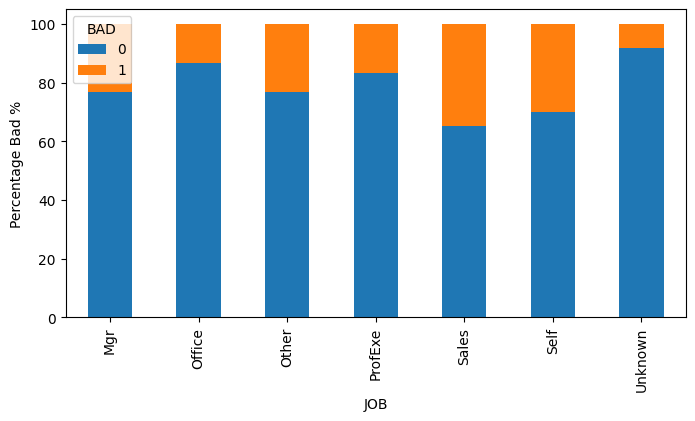

In [14]:
for i in cat_cols:
    if i != 'BAD':
        (pd.crosstab(df[i], df['BAD'],normalize = 'index')*100).plot(kind='bar',figsize= (8,4), stacked = True)
        plt.ylabel('Percentage Bad %')


**Observations:**


*   The plot shows that the loan reasons are helpful but subtle predictors.While there is a visible difference between the groups, the default rate stays roughly between $18\%$ and $22\%$ across all three categories.
*   Borrowers taking out a loan for home improvement (HomeImp) actually default at a slightly higher rate (the orange bar is noticeably taller, sitting right around $22\%$) than those borrowing for debt consolidation (DebtCon), which sits just under $19\%$.

*   Applicants with an undisclosed reason (Unknown) show a default rate almost identical to the debt consolidation group (around $19\%$).


*  Unlike the loan reasons, where default rates were all pretty close, the JOB feature is a highly predictive one for the models.
*   Sales and Self Employed are at the highest risk of default with sales & self at 35% and 30% respectively.



*   Managers & Executives sit right in the middle at 23% and 17% default rate.
*   Office workers & Unknowns are the lowest risk. Office workers default at only 13% while unknown is about 8% (100-92)









**Check the relationship between Target Variable(BAD') and Numerical** *


In [15]:
# The mean of mumerical varibales grouped by BAD
df.groupby(['BAD'])[num_cols].mean()

,LOAN,MORTDUE,VALUE,YOJ,CLAGE,NINQ,CLNO,DEBTINC,DEROG,DELINQ
BAD,,,,,,,,,,
0,19028.107315,73982.084391,102576.318640,8.951687,186.349827,1.029763,21.270384,33.410921,0.116747,0.219032
1,16922.119428,69064.495013,97383.593616,7.971615,151.717152,1.733389,21.157275,36.367010,0.656013,1.154752


**Observations:**



*   The data clearly shows that risk is driven more by Credit history & Debt than by loan size.

*   DELINQ : Defaulters avaerage 5x increase than Non-Defaulters.

*   DEROG : Defaulters average 0.66 major derogatory remarks, while non-defaulters average a tiny 0.12.
*   DEBTINC : Defaulters spend a higher average chunk of their income on debt payments.

*   Borrowers who repay their loans (BAD = 0) have more established profiles. This is represented in CLAGE and YOJ as Non-Defaulters have siginificant older credit histories (186 months vs 151 months) and safe borrowers have longer job stability ( 8.95 yrs vs 7.97 yrs).

*   Surprisingly, larger loans and bigger houses have less impact on loan default as Non -Defaulters take out larger average loans (19,028 vs 16,922)and higher value homes(73,982 vs 69,064) than Defaulters.
* Overall the data indicates that high loan amounts aren't inherently risky in this dataset rather a messy credit history combined with shorter job tenure and a higher debt-to-income ratio predicts default.











**MULTIVARIATE ANALYSIS**

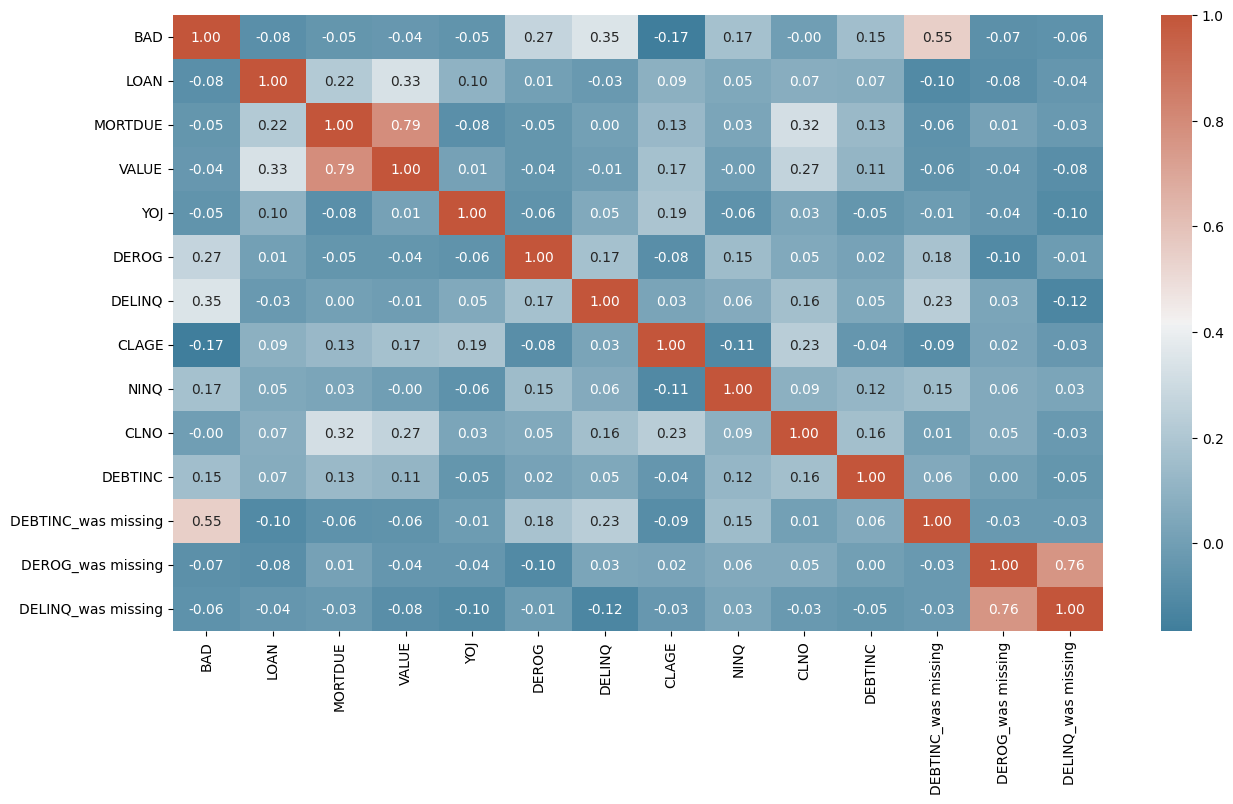

In [16]:
# plotting the correlation between numerical variables
plt.figure(figsize = (15,8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(df.corr(numeric_only= True),annot=True,fmt='.2f', cmap=cmap)
plt.xticks(rotation=90)
plt.show()

**Obseravtions:**



*   DEBTINC_was missing has the strongest correlation at 0.55. This means that it's a highly predictive feature for default. Borrowers who hide or fail to provide their debt-to-income metrics are vastly more likely to default.
*  As noted earlier, recent delinquencies and major derogatory marks  still showed up as the strongest numerical behavioral indicators of a default.


*  DEROG_was missing vs DELINQ_was missing at 0.76 correlations are completely linked meaning that if an applicant is missing data for derogatory remarks, they are almost always missing data for delinquencies too.

*   MORTDUE vs VALUE also show a very strong correlation. It makes total logical sense—the higher the market value of the property, the larger the outstanding mortgage on it tends to be.

*   Loan vs Value at 0.33 correlation means that people with higher-valued homes also tend to ask for larger home equity loan amounts.



*   The 0.79 correlation between MORTDUE and VALUE means they are completely linked and repeating information. With Linear models (like Logistic Regression), the 0.79 correlation can destabilize model coefficients due to Multicollinearity. However, Tree-based models like (Random Forests, XGBoost) can handle this perfectly well.








**Model Building-Approach**




1. Prepare the data for modeling.
2. Partition the data into train and test sets.
3. Build the model on the train data.
4. Tune the model if required.
5. Test the data on the test set.




**Preparing Data for modeling**

*  Separate numerical & categorical varibales
*   Using ColunmTransformer inplace of Get_dummy, Scale the Data and MAP binary categorical features.



In [17]:
#Scale, Encode & leave _was_missing values by using remainder= passthrough

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define the transformer setup
preprocessor = ColumnTransformer( transformers=[('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols) ],
    remainder='passthrough')# to encode & keep _was_missing flags intact

# Separate features (X) from your target variable (y)
X = df.drop(columns=['BAD'])
y = df['BAD']

# Transform your features into the final numeric matrix for modeling(SCALING)
X_processed = preprocessor.fit_transform(X) # Scale data


**SPLITTING THE DATA**

In [18]:
# Splitting data into 70% Train and 30% Test sets
x_train, x_test, y_train, y_test = train_test_split(X_processed, y, test_size = 0.3, random_state = 1, stratify = y)

**Model Evaluation Criterion**

The model can make two types of wrong predicitons:


1.   Predicting a default when they don't (False Positive) results in lost opportuinty cost as the bank turns away from a good customer.

2.   Predicting no default when they actually do (False Negative) results in a direct financial loss as the bank approves a bad loan.

False Negatives are significantly more critical in this business context. Giving money to a borrower who defaults is far more costly to the bottom line than missing out on a potential customer. Therefore, the primary modeling goal is to maximize Recall to minimize these severe misses.

**Create a function to calculate classification report and confusion matrix**

In [19]:
# Creating metric function
def metrics_score(actual, predicted):

    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True, fmt = '.2f', xticklabels = ['Not BAD', 'BAD'], yticklabels = ['Not BAD', 'BAD'])

    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

In [20]:
# function to compute different metrics to check classification model performance
# model : classifier, predictors : independent variables, target : dependent variable

def model_performance_classification(model, predictors, target):

    # predicting using the independent variables
    pred = model.predict(predictors)

    # SCORING THE MODEL
    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred, average = 'macro')
    precision = precision_score(target, pred, average = 'macro')

    # creating a dataframe of metrics
    df_perf =pd.DataFrame({
        'Metric': ['Accuracy', 'Recall', 'Precision'],
        'Score': [acc, recall, precision]
    })

    return df_perf

**Building the Model**

The three models that will be built are:


1.   Logistic Regression
2.   Decision Tree
3.   Random Forest



LOGISTIC REGRESSION

 Logistic Regression is a supervised learning algorithm, generally used for binary classification problems, i.e., where the dependent variable is categorical and has only two possible values. In logistic regression, we use the sigmoid function to calculate the probability.




In [21]:
# Fitting the Logistics Regression Model
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      3340
           1       0.78      0.59      0.67       832

    accuracy                           0.88      4172
   macro avg       0.84      0.77      0.80      4172
weighted avg       0.88      0.88      0.88      4172



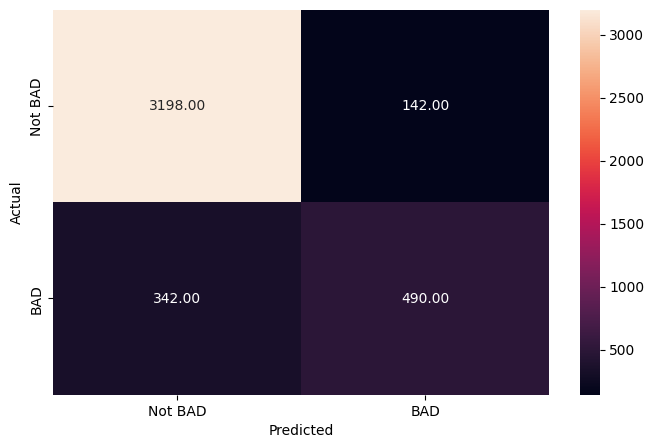

In [22]:
# check performance on the training data
y_pred_train = log_reg.predict(x_train)
metrics_score(y_train, y_pred_train)

              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1431
           1       0.76      0.56      0.65       357

    accuracy                           0.88      1788
   macro avg       0.83      0.76      0.79      1788
weighted avg       0.87      0.88      0.87      1788



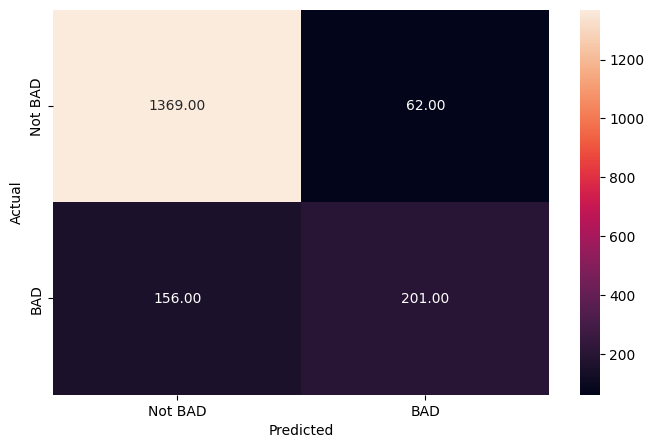

In [23]:
# Checking the performance on the test dataset
y_pred_test = log_reg.predict(x_test)
metrics_score(y_test, y_pred_test)

**Observations:**

Strong Overall Accuracy: Both models maintain a solid overall accuracy of 88%, demonstrating a strong ability to classify the vast majority of loans correctly across the entire dataset.

Excellent Safe-Loan Detection: The models excel at identifying dependable borrowers (Class 0), achieving an exceptional 90% precision and 96% recall. If a loan is genuinely safe, the model almost never misses it.

Underperforming Defaulter Detection (Recall Lag): While precision for defaults (Class 1) is decent at 76%–78%, the recall drops to 56%–59%. This means the model is failing to catch roughly 40% of the actual risky borrowers, letting them slip through the system unnoticed.

High-Cost False Negatives: Looking at the bottom-left quadrants of the matrices, the models flag 342 and 156 actual defaults as Not BAD. From a risk-management perspective, these missed defaults represent the highest financial liability for the business.

While 88% accruacy looks great,it's also a trap because the dataset has way more good loans than bad ones, the model has learned how to safely say "Yes" to good applicants, but it remains too weak at sniffing out the risky ones. A high Recall is needed for risk management and this model falls short at handling it.

**Check for Coefficient**

Checking for coefficient to understand the variables leading to loan default and variables that can reduce it

In [24]:
# Coefficients of Logistic Regression
cols= preprocessor.get_feature_names_out()
coef_log_reg = log_reg.coef_
pd.DataFrame(coef_log_reg, columns=cols).T.sort_values(by=0, ascending=False)

,0
remainder__DEBTINC_was missing,2.657939
num__DELINQ,0.825588
num__DEBTINC,0.666000
cat__JOB_Sales,0.661771
remainder__DELINQ_was missing,0.505333
num__DEROG,0.397703
cat__JOB_Self,0.305393
cat__REASON_HomeImp,0.222452
num__VALUE,0.191866
num__NINQ,0.170771


**Observations:**



*   The benchmark for coeffiecient is 0
*   Features with high positive numbers like 'DEBTINC_was_missing' are the strongest red flags for a loan default while features with negative numbers like 'CLAGE', reduce the risk of default





The coefficients of the logistics regression gives log of odds that is difficult to interpret in real world. Therefore the log of odds will be converted by taking its exponential.

In [25]:
odds_log_reg = pd.DataFrame(np.exp(coef_log_reg), columns=cols).T.sort_values(by=0, ascending=False)
odds_log_reg.columns = ['Odds']
odds_log_reg

,Odds
remainder__DEBTINC_was missing,14.266851
num__DELINQ,2.283224
num__DEBTINC,1.946437
cat__JOB_Sales,1.938222
remainder__DELINQ_was missing,1.657538
num__DEROG,1.488401
cat__JOB_Self,1.357158
cat__REASON_HomeImp,1.249136
num__VALUE,1.211508
num__NINQ,1.186219


**Observations:**



*   In Odds Ratios, the benchmark is 1
*   Numbers greater than 1 mean higher risk while numbers less than 1 mean lower risk. For example an applicant whose debt-to-income ratio is missing is 14.26 times more lilely to default than an applicant with a lower ratio



**The Precision-Recall Curve for Logistic Regression**

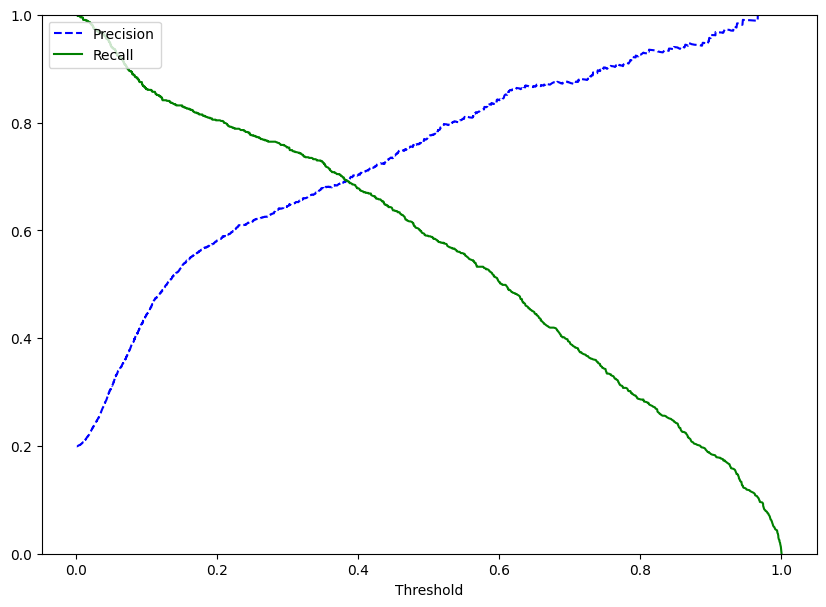

In [26]:
# Get the probability scores for the positive class (default)
y_scores_log = log_reg.predict_proba(x_train)[:, 1]

# Feed those scores directly into the precision-recall curve function
precisions_log, recalls_log, thresholds_log = precision_recall_curve(y_train, y_scores_log)

# Plot values of precisions, recalls, and thresholds
plt.figure(figsize =(10,7))
plt.plot(thresholds_log, precisions_log[:-1], "b--", label="Precision")
plt.plot(thresholds_log, recalls_log[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend(loc="upper left")
plt.ylim([0, 1])
plt.show()

#

**Observations:**

Since the dataset is heavily imbalanced, with 3,340 safe loans vs 832 defaults and the model is great at predicting majority class. However, Precision Recall  forces the model to focus on the minority-the defaults. It will also help to choose a new custom probability threshold as opposed to the standard 50%

*   As shown in the plot, the standard threshold of Balanced Point of 50% has moved to about 40% - the intersection
*  Moving the models's threshold from 50% to about 33% will instantly balance the model performance because the recall will be at higher point while still maintaining a good precision point.

*   At 0.30 to 0.35 threshold, model will show that it is much better to accidentally annoy a few good customers with extra background checks (False Positives) than it is to accidentally hand out a $40,000 loan to someone who will default and never pay it back (False Negatives).






**Checking Performance of the model at this threshold**

              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3340
           1       0.66      0.73      0.70       832

    accuracy                           0.87      4172
   macro avg       0.80      0.82      0.81      4172
weighted avg       0.88      0.87      0.88      4172



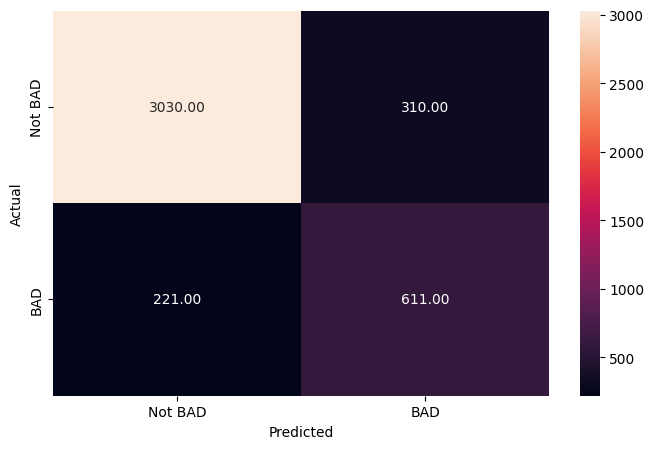

In [27]:
#check for Train dataset
optimal_threshold1 = .33
y_pred_train =log_reg.predict_proba(x_train)
metrics_score(y_train, y_pred_train[:, 1] > optimal_threshold1)

              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1431
           1       0.66      0.70      0.68       357

    accuracy                           0.87      1788
   macro avg       0.79      0.80      0.80      1788
weighted avg       0.87      0.87      0.87      1788



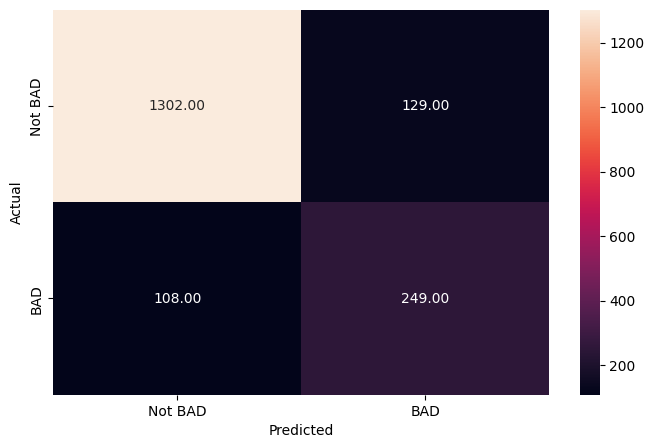

In [28]:
#check for Test dataset
optimal_threshold1 = .33
y_pred_test =log_reg.predict_proba(x_test)
metrics_score(y_test, y_pred_test[:, 1] > optimal_threshold1)

**Observations:**

*   No Overfitting. The model performs identically on both the Train (87% accuracy) and Test (87% accuracy) datasets. This proves the model has truly learned genuine financial risk patterns and will reliably handle new, unseen loan applications.
*   By lowering the threshold to 0.33, the default Recall held strong at 70% on the test set (and 73% on train). Compared to the original model's weak 56% test recall, this new model has successfully locked down the blind spot and caught
the vast majority of defaults.


*  In the test set, the dangerous False Negatives (missed defaults) dropped from 156 down to just 108. The model successfully intercepted 48 additional high-risk borrowers, protecting the portfolio's capital from bad debt write-offs.




**Building a Decision Tree Model**

Build a Class Distribution of the Target variable('BAD'):


In [29]:
# Percentage class distribution of the target variable
df['BAD'].value_counts(1)*100

,proportion
BAD,
0,80.050336
1,19.949664


**Observations:**



*  80% of the data represents good loans (0)
*  20% of the data represents defaults (1)



In [30]:
# Building decision tree model
dt = DecisionTreeClassifier(class_weight = {0:0.20, 1 : 0.80},random_state=1)
dt.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=1)

**Check Model Performance of decision tree**

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



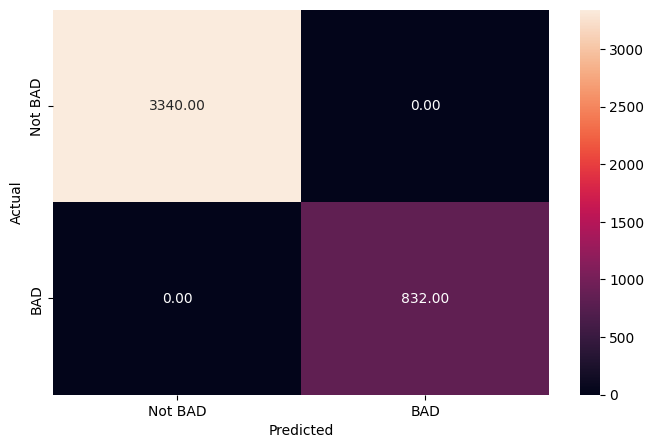

In [31]:
# Checking performance on train dataset
y_train_pred_dt = dt.predict(x_train)
metrics_score(y_train, y_train_pred_dt)

**Observation:**



*   The model has achieved a flawless 1.00 (100%) accuracy, precision, and recall. It made exactly zero mistakes on the training data, meaning the decision tree grew completely unconstrained until it perfectly memorized every single row in your dataset.


*   The confusion matrix shows 0.00 False Negatives and 0.00 False Positives. While a zero-fault model looks amazing on paper, it is a massive red flag in data science; the model has essentially created a custom rule for every individual borrower rather than learning generalized risk behaviors.



*   To make this a viable production model, you will need to restrict its growth in the next steps. Implementing hyperparameters like max_depth, min_samples_split, or switching to a pruned cost-complexity approach is necessary to force the tree to generalize.






              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1431
           1       0.70      0.60      0.64       357

    accuracy                           0.87      1788
   macro avg       0.80      0.77      0.78      1788
weighted avg       0.86      0.87      0.86      1788



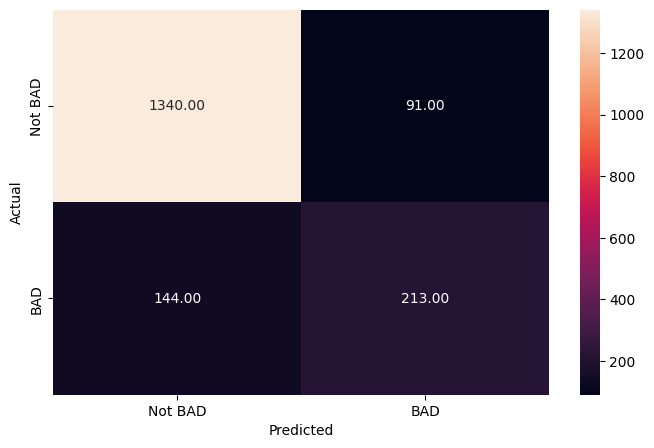

In [32]:
# Checking performance on test dataset
y_test_pred_dt = dt.predict(x_test)
metrics_score(y_test, y_test_pred_dt)

**Observations:**



*  Overall accuracy dropped from a perfect 1.00 (100%) on train down to 0.87 (87%) on test, confirming the overfitting. While 87% is a decent baseline score, the sharp drop proves the model couldn't replicate its memorized training success on new, unseen data.

*   Precision dropped from 1.00 to 0.70. Recall plummeted from 1.00 down to a weak 0.60.

*   The confusion matrix exposes the real-world danger of this unpruned tree. It missed 144.00 defaults (False Negatives), letting high-risk borrowers slip through because it built hyper-specific training rules that don't apply to real life.

*  This raw decision tree is a much riskier business strategy for the loan portfolio even when compared to the Tuned Logistic Regression model which had 0.70 Test Recall & 108 False Negatives





**Checking the Macro Average of the Model**

In [33]:
dtree_test = model_performance_classification(dt, x_test, y_test) # blended average of both classes
dtree_test

,Metric,Score
0,Accuracy,0.868568
1,Recall,0.766523
2,Precision,0.801811


**Observations:**


*   Accuracy: Out of all the loan applications in the test set, the model guessed correctly (both safe and default) roughly 87% of the time.

*   Recall: The model is not catching 76.6% of the actual defaults. It is actually only catching 59.7% (about 60%) of the actual defaults (213 out of 357). The 76.6% is an average inflated by the model's excellent ability to find good loans.

*   Precision: When this model flags an applicant as a default risk (BAD), it is not correct 80.1% of the time.it is only correct 70.1% of the time (213 out of 304 total predicted bad loans).











**Plot for Feature Importance and check the most important features**

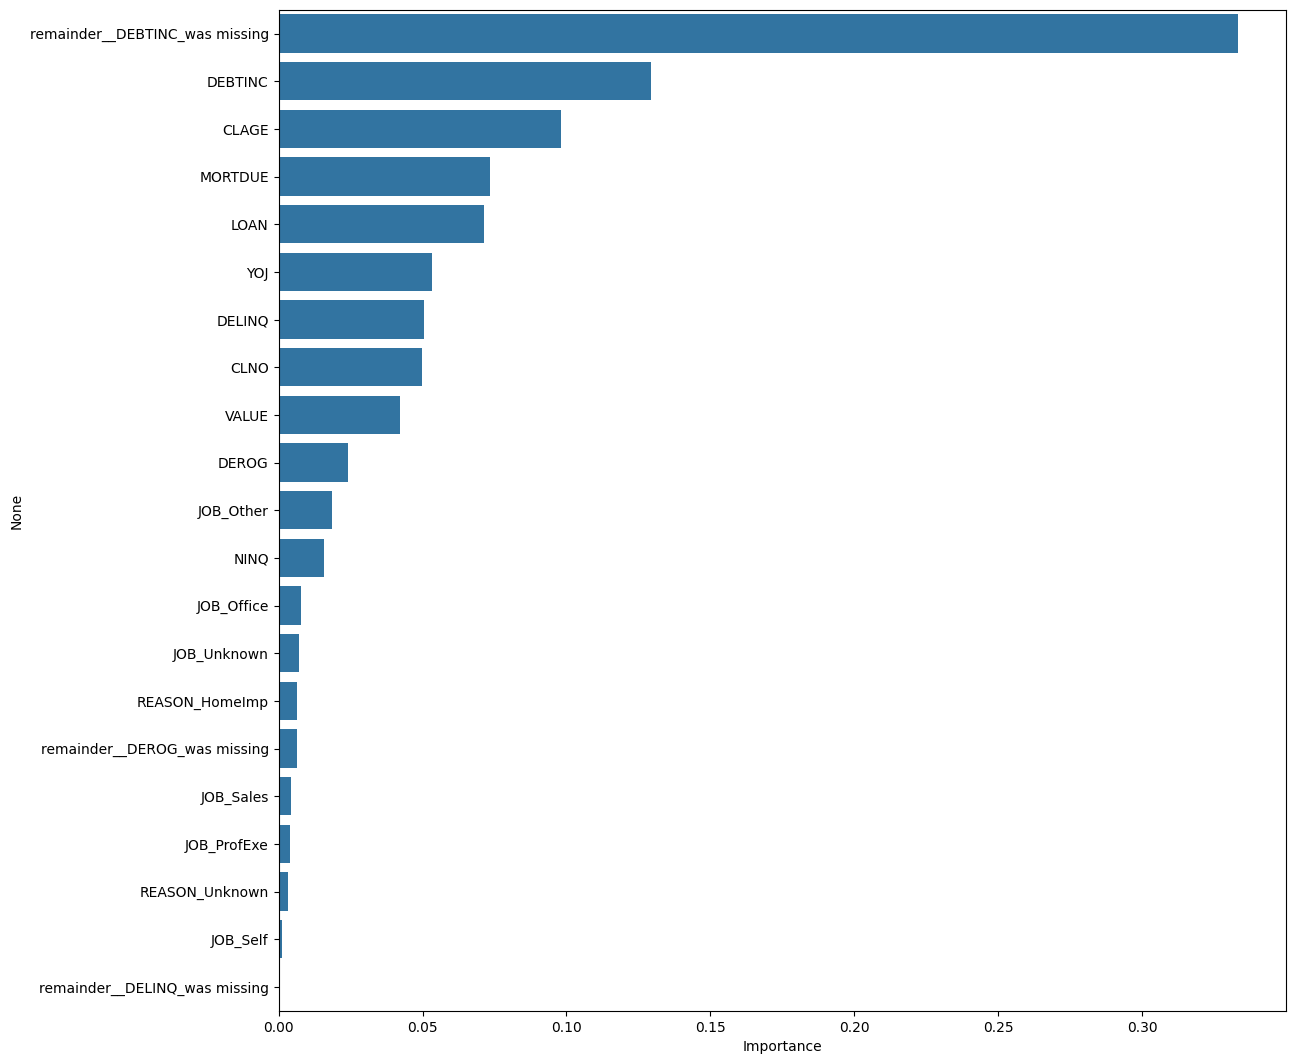

In [34]:
# Plot feature importance

importances = dt.feature_importances_

# Extract the correct 21 feature names from preprocessor
columns = preprocessor.get_feature_names_out() # use col. processor rather than standard col

#  Create, sort, and plot the DataFrame
importance_df = pd.DataFrame(importances, index=columns, columns=['Importance'])
importance_df= importance_df.sort_values('Importance', ascending=False)

# Setup the plot size
plt.figure(figsize=(13, 13))

# to clean prefixes
importance_df.index = importance_df.index.str.replace('num__', '').str.replace('cat__', '')

#  Draw the barplot
sns.barplot(x=importance_df.Importance, y=importance_df.index)

plt.show()


**Observations:**


The model doesn't care what the customer says they do for a living; it focuses almost entirely on whether they are overleveraged (DEBTINC) and how long they've managed credit (CLAGE), with a massive penalty if their critical debt data is missing entirely."

**Decision Tree-Hyperparameter Tuning**

In [35]:
# Choose Type of Classifier
dt_estimator = DecisionTreeClassifier(class_weight = {0:0.20, 1 : 0.80},random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': np.arange(2, 7),'criterion': ['gini', 'entropy'], 'min_samples_leaf': [5, 10, 20, 25]}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(recall_score, pos_label = 1)

# Run the grid search
gridCV = GridSearchCV(dt_estimator, parameters, scoring = scorer, cv = 10)

# Fitting the grid search on the train data
gridCV = gridCV.fit(x_train, y_train)

# Set the classifier to the best combination of parameters
dt_estimator = gridCV.best_estimator_

# Fit the best estimator to the data
dt_estimator.fit(x_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, max_depth=np.int64(5),
                       min_samples_leaf=20, random_state=1)

              precision    recall  f1-score   support

           0       0.94      0.90      0.92      3340
           1       0.67      0.78      0.72       832

    accuracy                           0.88      4172
   macro avg       0.80      0.84      0.82      4172
weighted avg       0.89      0.88      0.88      4172



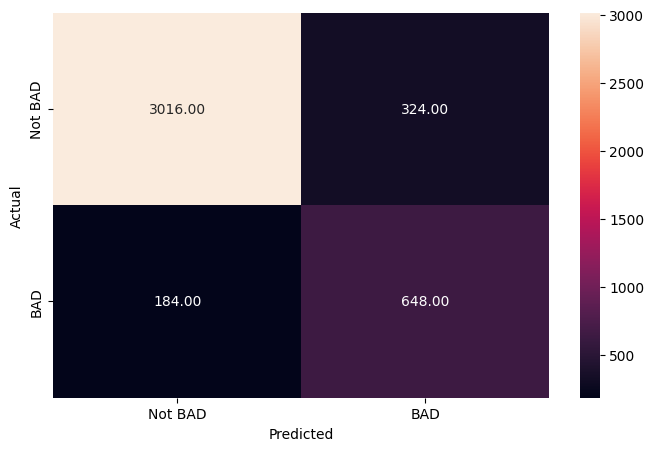

In [36]:
# Checking performance on Train dataset
y_train_pred_dt = dt_estimator.predict(x_train)
metrics_score(y_train, y_train_pred_dt)

**Observation:**



*   Accuracy is no longer a fake 100%. It dropped to a healthy, realistic 88%. This means the model is no longer memorizing individual rows row-by-row; instead, it's learning generalized risk rules that will actually hold up on unseen test data.

*  In Class 1 (BAD) metrics, Recall is at 78% and Precision is at 67%. Rather than a perfect 1.00 built on training noise, these numbers represent a robust, balanced structure designed to catch genuine credit risks.


*   The model now intentionally makes mistakes on the training set because it is prioritizing general patterns over perfection. It missed 184 defaults (False Negatives) and flagged 324 safe borrowers as risky (False Positives). This is exactly what a healthy, production-ready credit model looks like before it meets the test set.

*   Because these training numbers are grounded and realistic, you can expect the upcoming test set metrics to align very closely with this 88% accuracy. The massive performance drop-off you experienced with the first tree is completely gone.





              precision    recall  f1-score   support

           0       0.93      0.90      0.92      1431
           1       0.65      0.72      0.68       357

    accuracy                           0.87      1788
   macro avg       0.79      0.81      0.80      1788
weighted avg       0.87      0.87      0.87      1788



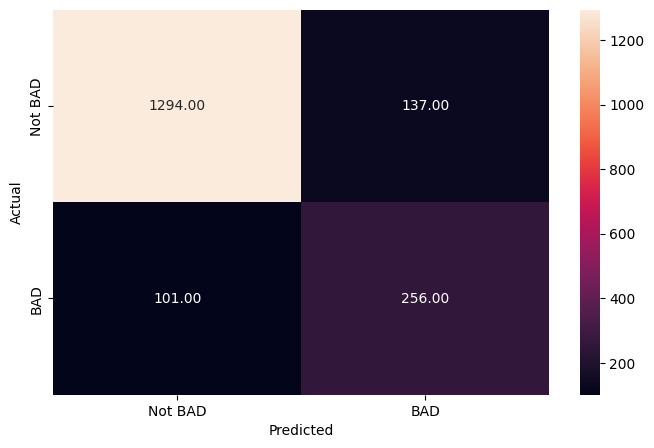

In [37]:
# Checking performance on Test dataset
y_test_pred_dt = dt_estimator.predict(x_test)
metrics_score(y_test, y_test_pred_dt)

In [38]:
dt_tune_test = model_performance_classification(dt_estimator, x_test, y_test)
dt_tune_test

,Metric,Score
0,Accuracy,0.866890
1,Recall,0.810675
2,Precision,0.789499


**Observations**:


*   Test accruacy at 86.7% vs 88% train set.The tiny drop between train and test proves that the model successfully generalized its patterns. The severe overfitting gap from the original, unpruned tree has been completely eliminated.

*   Recall is 72%: Out of 357 actual defaults, the model caught 256 of them.


*   Precision is 65%: When the model flags someone as high risk, it is correct nearly two-thirds of the time.

*  Tuned Logistic Regression (Threshold 0.33): Highly explainable, catches 70% of defaults, and leaves 108 False Negatives.

*   Tuned Decision Tree (dt_estimator): Non-linear, slightly better risk mitigation (catches 72% of defaults), and reduces False Negatives down to 101.








**Check on Feature Importance of this Model**

<Axes: xlabel='Importance', ylabel='None'>

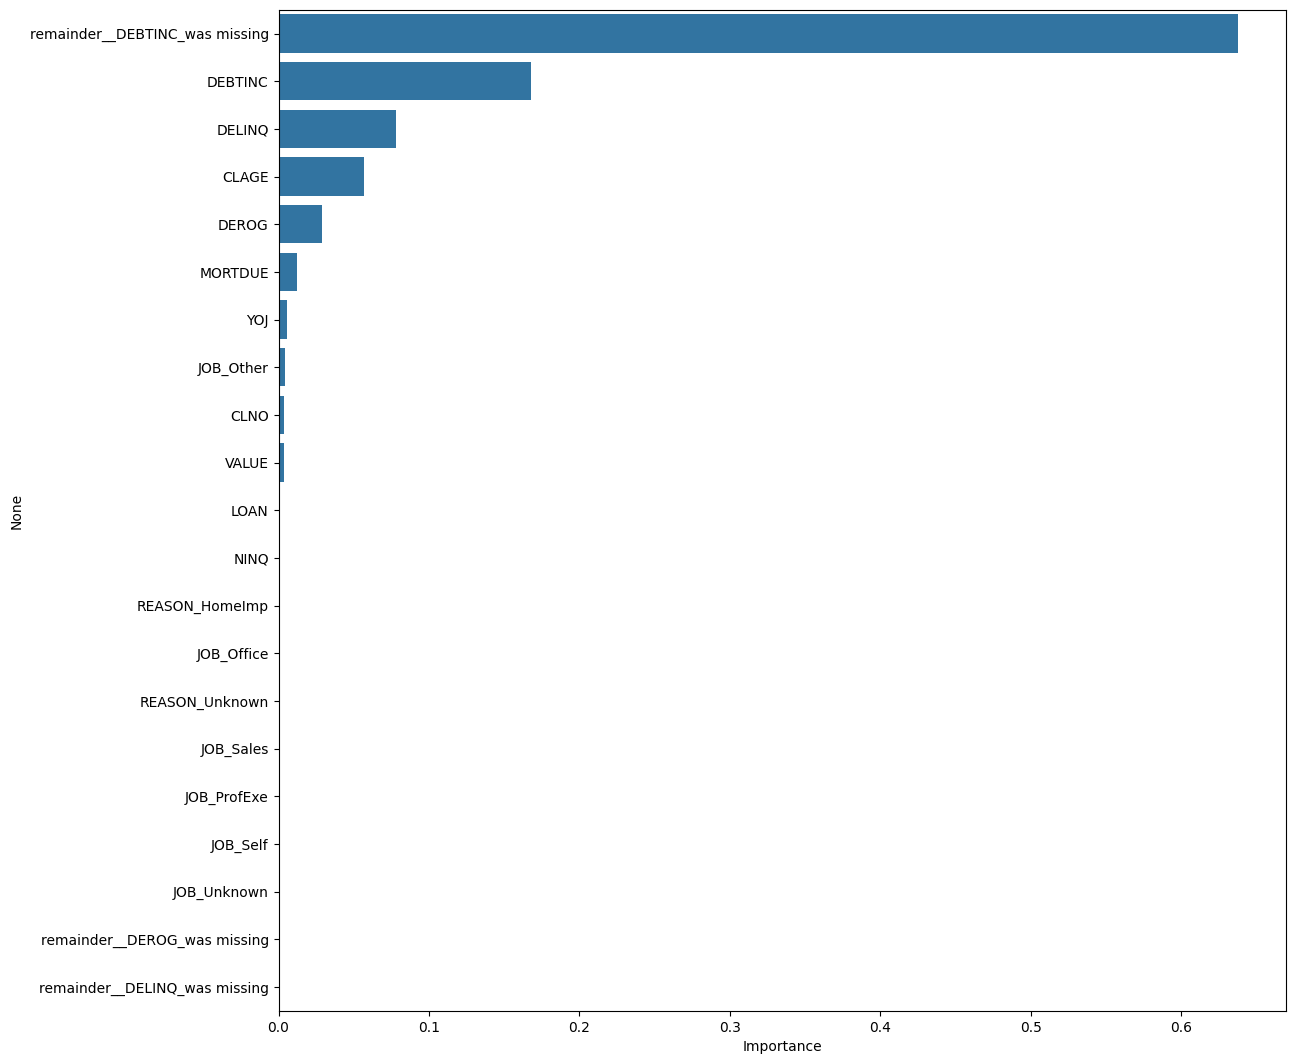

In [39]:
# Plot feature importance

importances = dt_estimator.feature_importances_

# Extract the correct 21 feature names from preprocessor
columns = preprocessor.get_feature_names_out() # use col. processor rather than standard col

#  Create, sort, and plot the DataFrame
importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)


# Setup the plot size
plt.figure(figsize=(13, 13))

# to clean prefixes
importance_df.index = importance_df.index.str.replace('num__', '').str.replace('cat__', '')

#  Draw the barplot
sns.barplot(x=importance_df.Importance, y=importance_df.index)




**Observations:**




*   The tuned model's feature importnace dropped off sharply when compared to the previos unpruned tree. After the top 4–5 variables, the importance bars flatten out to almost zero. This is a visual proof that the hyperparameter tuning successfully restricted the tree. Instead of creating thousands of tiny, hyper-specific branches for irrelevant features (like JOB or VALUE), the model is strictly forced to make its major credit decisions using only a core handful of high-impact variables.

*  While DEBTINC_was_missing and DEBTINC remain the primary anchors of risk, the secondary drivers have shifted position with DELINQ taking the 3rd position and CLAGE  in the 4th position,, confirming that credit history longevity is a foundational rule the model relies on to verify reliability.



*   The feature importance highlighted how this tuned model ignores that majority noise that the previuos unpruned Decision Tree wasted energy in memorizing. By focusing heavily on DEBTINC, DELINQ, and CLAGE, it targets the exact financial pain points that cause a borrower to fall into that vulnerable 20% default bucket.




**Plotting the tree**

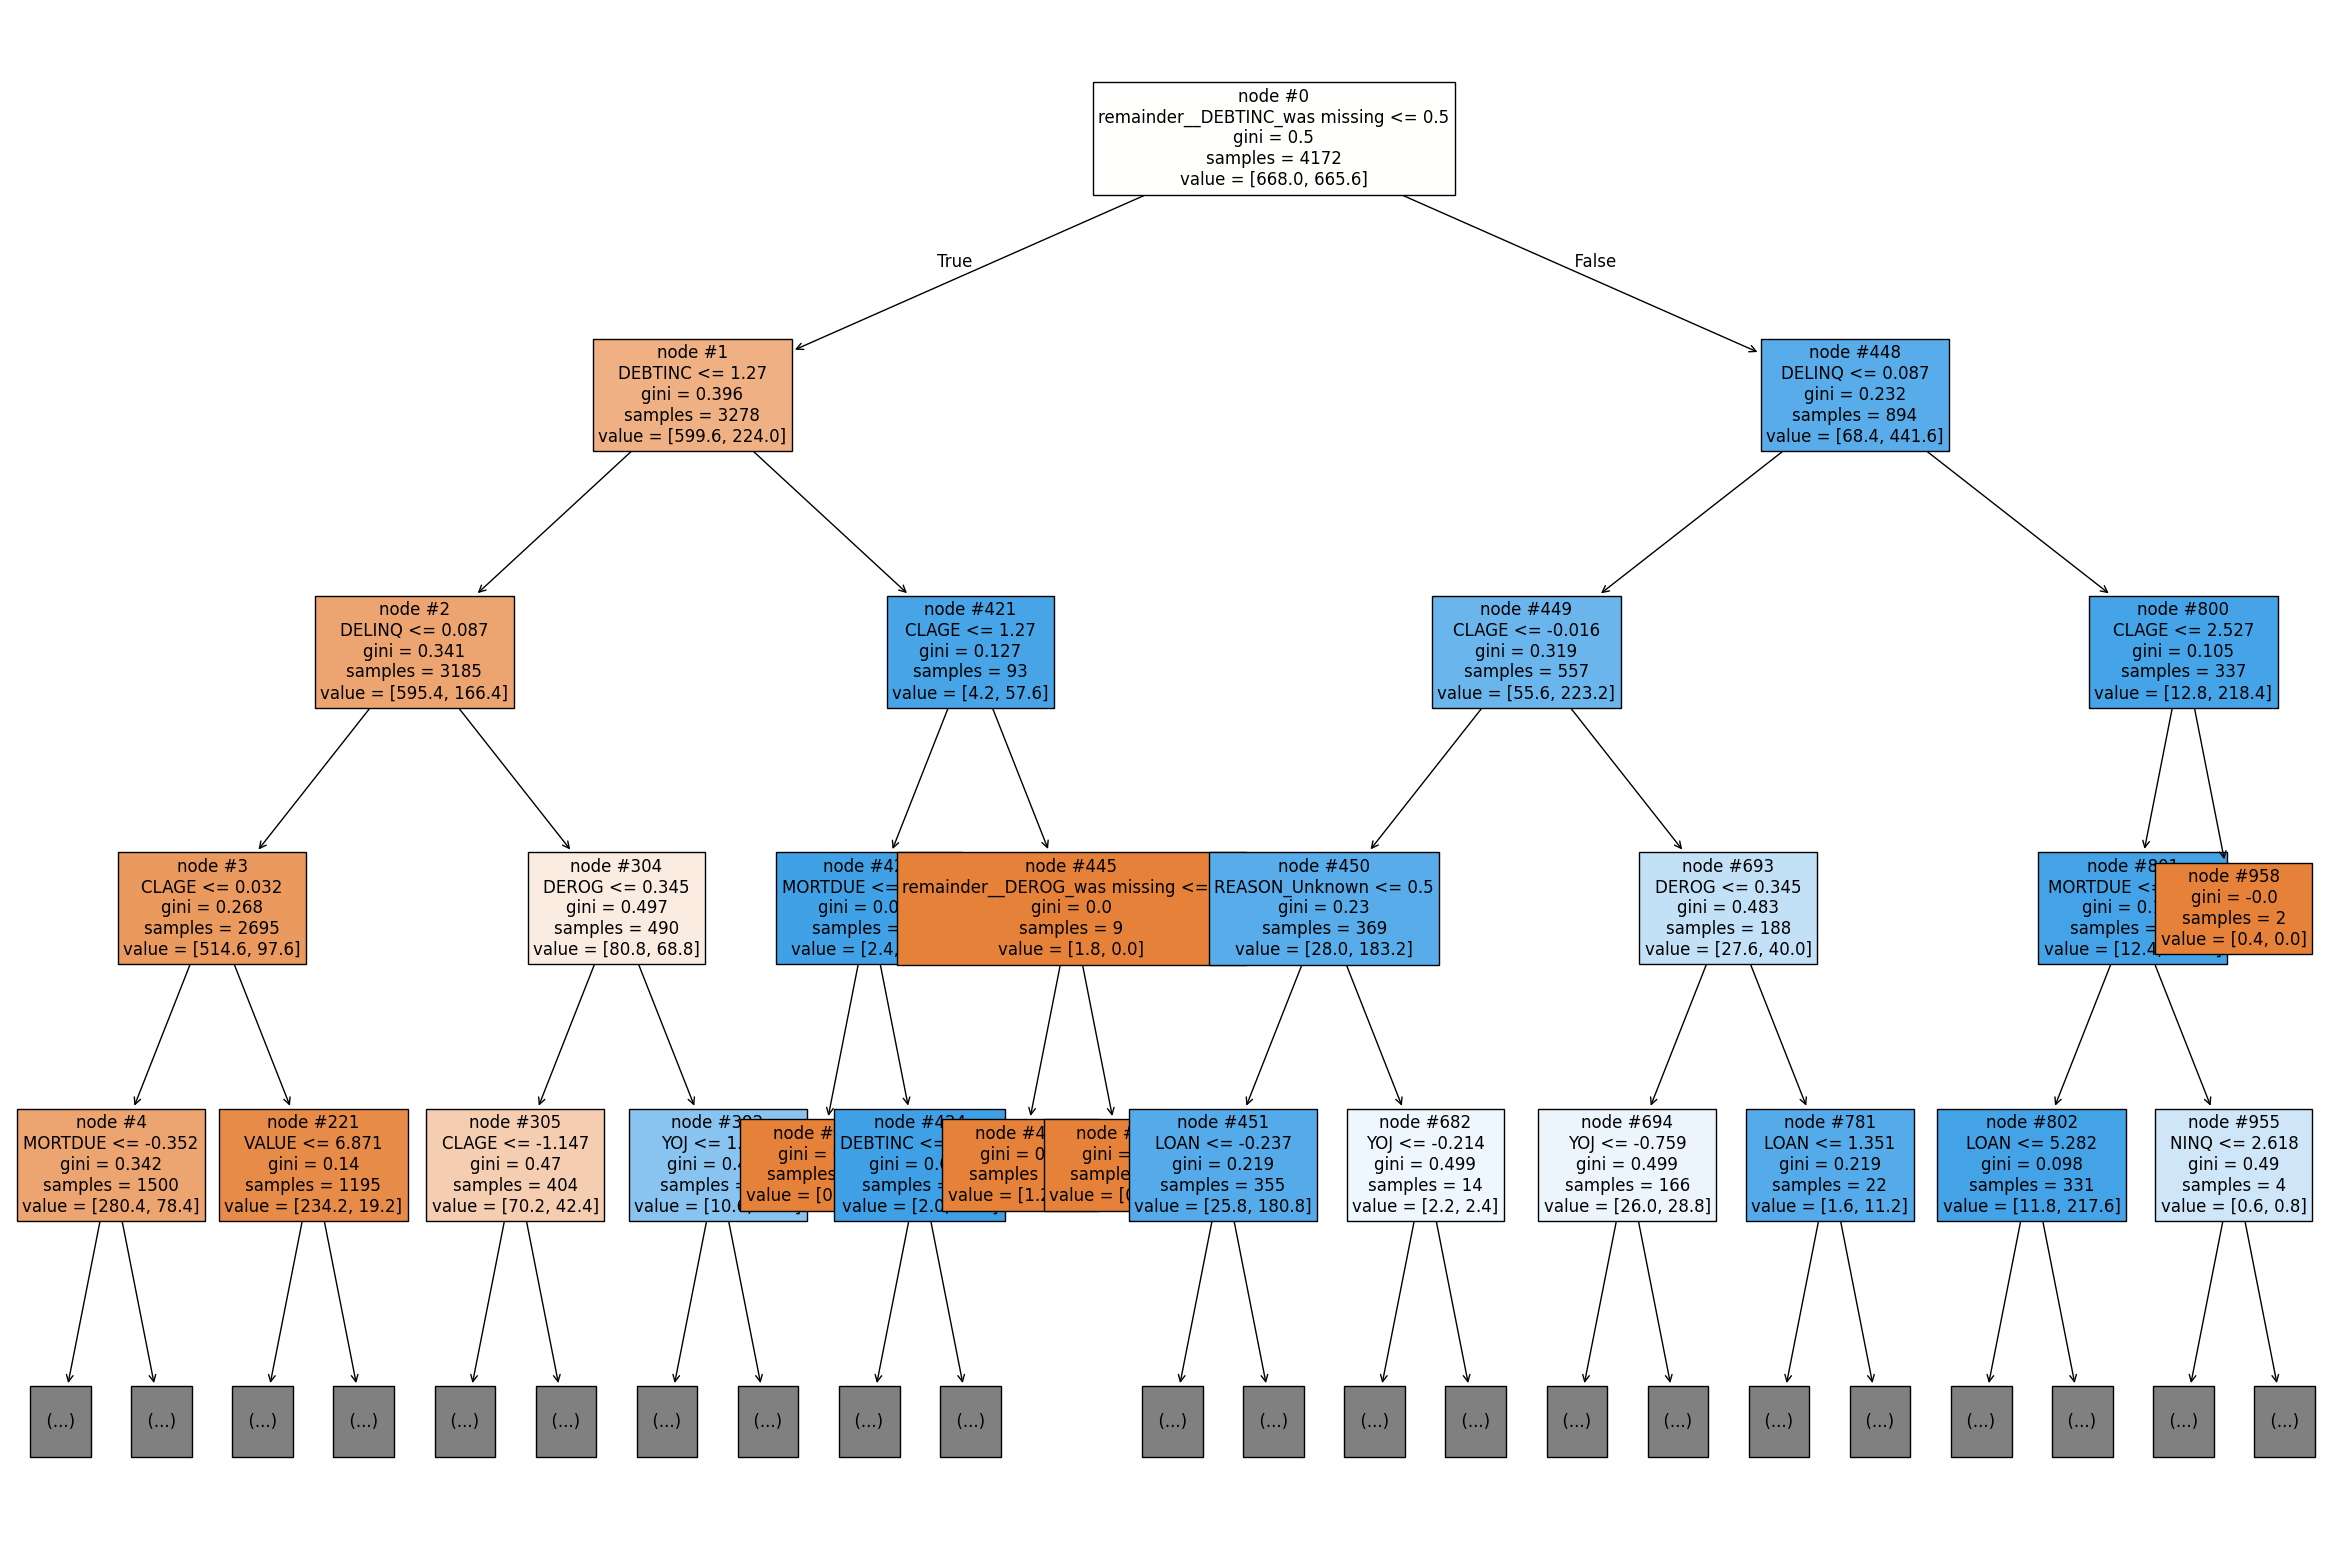

In [40]:
# Get the correct 21 feature names from the preprocessor

features = list(preprocessor.get_feature_names_out())


# Clean the prefixes so the labels inside the tree look readable
features = [f.replace('num__', '').replace('cat__', '') for f in features]

plt.figure(figsize = (30, 20))

tree.plot_tree(dt, max_depth = 4, feature_names = features, filled = True, fontsize = 12, node_ids = True, class_names = None)

plt.show()

**Observations:**

The Tree confirms what the feature importance plot hinted at. The very first question the tree asks isn't how much money someone makes; but rather did they provide their debt-to-income paperwork?




*   Orange Nodes lean toward safe loans(0), Blue Nodes lean heavily towards default(1) while the Dark Blue indicates a concentrated cluster of bad loans.




*   0.5 acts as the threshold between "True" and "False".

*  The Root Split starts at the top with remainder_DEBTINC_was_missing<=0.5.

*   Left Branch is True while Right Branch is False.

*   The Debt-to-Income ratio is present (not missing). The model channels 3,278 applicants down this paths.

*   The Debt-to-Income ratio is missing. The model channels 894 applicants directly down this path.









**BUILDING A RANDOM FOREST CLASSIFIER**

In [41]:
# Fitting the Random Forest classifier on the training data
rf_estimator = RandomForestClassifier(class_weight = {0: 0.2, 1: 0.80}, random_state = 1)

rf_estimator.fit(x_train, y_train)

RandomForestClassifier(class_weight={0: 0.2, 1: 0.8}, random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3340
           1       1.00      1.00      1.00       832

    accuracy                           1.00      4172
   macro avg       1.00      1.00      1.00      4172
weighted avg       1.00      1.00      1.00      4172



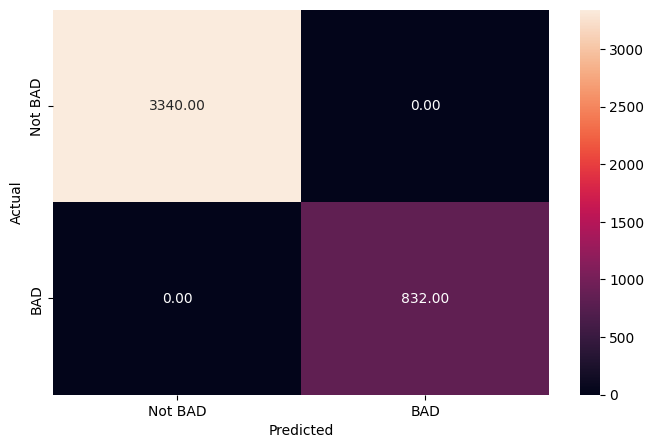

In [42]:
# Checking performance on the training data
y_pred_train_rf = rf_estimator.predict(x_train)

metrics_score(y_train, y_pred_train_rf)

**Observations:**



*   This is pure memorization by the train dataset . Model achieved a perfect 1.00 (100%) precision, recall, and f1-score across both classes, resulting in an overall accuracy of 1.00.

*   The confusion matrix confirms there are exactly 0.00 False Negatives and 0.00 False Positives. Out of 4,172 total rows, every single safe loan (3,340) and default (832) was perfectly classified.



*   Even though the parameter class_weight={0: 0.2, 1: 0.8} was passed to heavily penalize missing a default, the individual trees in this forest were given total freedom to grow without restrictions like max_depth or min_samples_split. Because they could split indefinitely, they didn't need to leverage the class weights to compromise; they simply memorized the data line-by-line.

*   Model is overfitted because it has perfectly captured all the noise of the training sample.





              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1431
           1       0.83      0.62      0.71       357

    accuracy                           0.90      1788
   macro avg       0.87      0.79      0.82      1788
weighted avg       0.89      0.90      0.89      1788



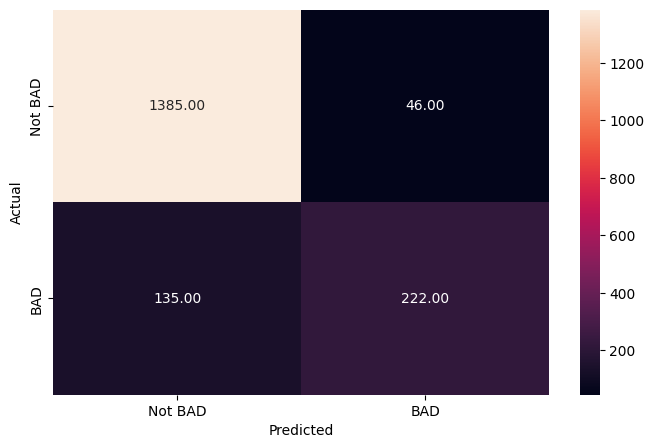

In [43]:
 # Checking performance on the testing data
y_pred_test_rf = rf_estimator.predict(x_test)

metrics_score(y_test, y_pred_test_rf)


In [44]:
rf_estimator_test = model_performance_classification(rf_estimator,x_test,y_test)
rf_estimator_test


,Metric,Score
0,Accuracy,0.898770
1,Recall,0.794852
2,Precision,0.869771


**Observations:**



*   The Class 1 (BAD) Recall has dropped down to 62%. Meaning out of 357 actual defaults in the test data, the Random Forest caught 222 (True Positives) but completely missed 135 (False Negatives). Missing $38\%$ of risky borrowers means this untuned forest leaves a sizeable blind spot for credit risk exposure.


*   The Class 1 Precision is quite strong at 83%. When this Random Forest explicitly flags someone as a default risk (BAD), it is correct $83\%$ of the time (222 out of 268 total predicted defaults). This means it creates very few false alarms (only 46 False Positives), so you won't accidentally alienate many good paying customers.

*   Compared to the raw, unpruned baseline decision tree (which had a test precision of $70\%$ and recall of $60\%$), this baseline Random Forest is a definitive upgrade. By utilizing an ensemble of many trees, it naturally boosted the precision to $83\%$ and recall to $62\%$ even without tuning.However, because it still missed 135 defaults, hyperparameter tuning or threshold adjustment is still the necessary next step to force this forest to drop its conservative guard and flag more of those hidden defaults









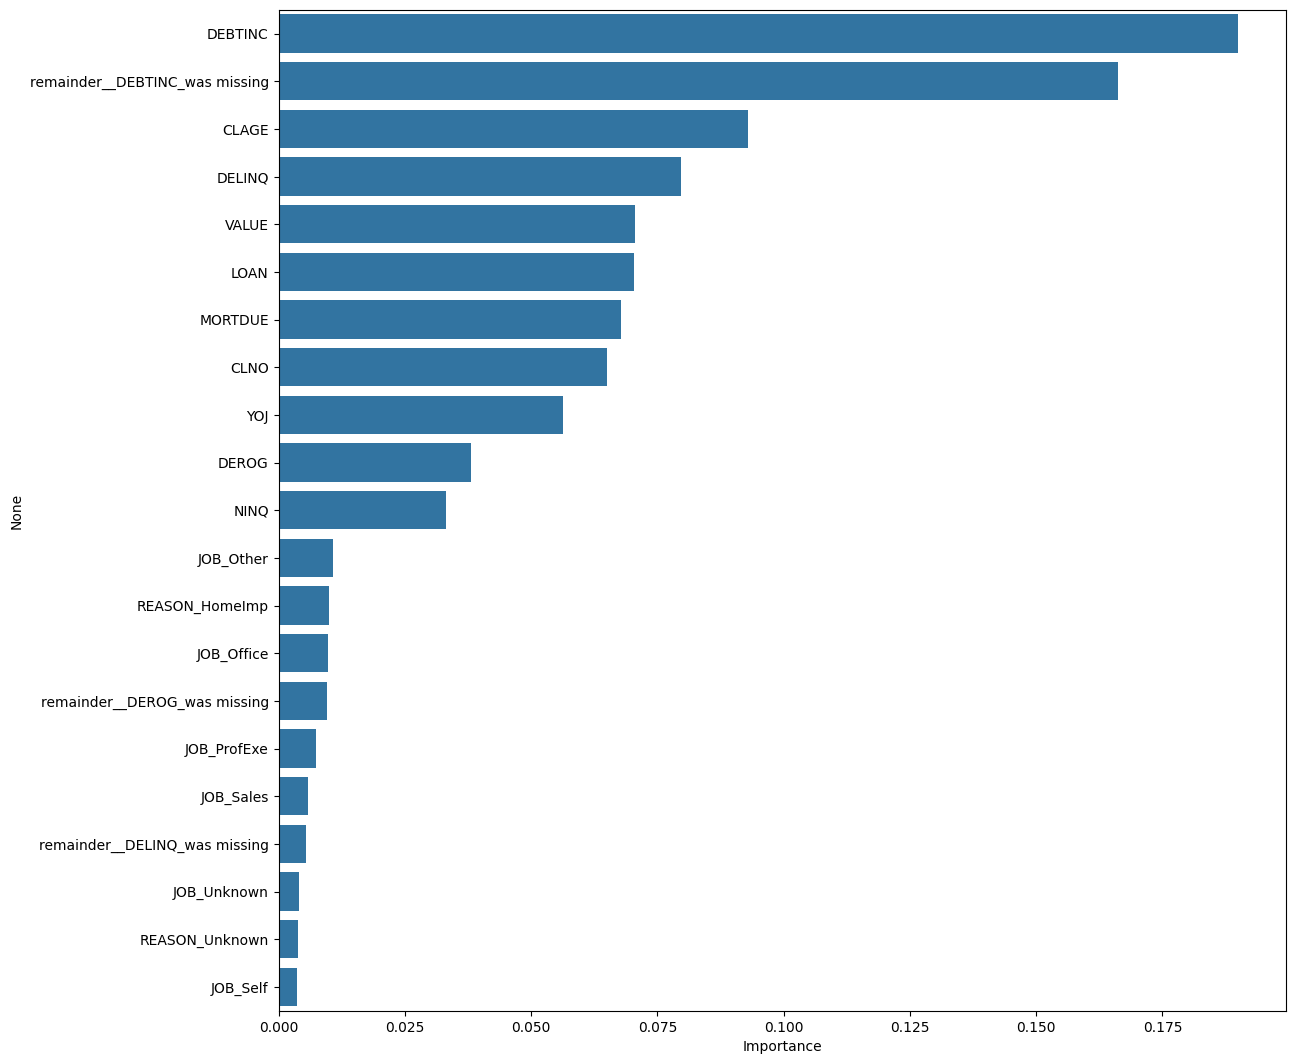

In [45]:
importances = rf_estimator.feature_importances_

features = list(preprocessor.get_feature_names_out())

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

# Strip out 'num__' and 'cat__' prefixes so labels look clean
importance_df.index = importance_df.index.str.replace('num__', '').str.replace('cat__', '')

plt.figure(figsize = (13, 13))

sns.barplot(x= importance_df.Importance, y=importance_df.index);

**Observations:**



* Whether you look at a single tree or a forest of trees, your model recognizes that a missing or high debt-to-income ratio is the ultimate predictor of default.

*   In Random Forest, the feature drop-offs are more gradual. This gradual spread is exactly how Random Forests fix the overfitting issues.


*   Features like VALUE, LOAN, and MORTDUE have significantly longer bars now and are playing an active role in the model.





**Tuning the Random Forest Classifier**

In [46]:
# Initialize Classifier
rf_estimator_tuned = RandomForestClassifier(class_weight={0: 0.2, 1: 0.80}, random_state=1)

# Grid of parameters to choose from. Fast Grid Grid — testing 100 and 200 trees max
params_rf = { "n_estimators": [100, 200],  "min_samples_leaf": [2, 4],  "max_features": [0.7, 0.9]}

#  Type of scoring used to compare parameter combinations - recall score for class Scorer & Grid Search (Using all CPU cores)
scorer = metrics.make_scorer(metrics.recall_score, pos_label=1)
grid_obj = GridSearchCV(estimator=rf_estimator_tuned, param_grid=params_rf, scoring=scorer, cv=3, n_jobs =-1)      # n_jobs Drastically reduces computation rounds from 5 to 3

#  Fit on uppercase X_train
print("Training started... please wait a moment.")
grid_obj = grid_obj.fit(x_train, y_train)

#  Extract Best Parameters
rf_estimator_tuned = grid_obj.best_estimator_
print("Success! Grid Search complete. Best parameters found:", grid_obj.best_params_)

Training started... please wait a moment.
Success! Grid Search complete. Best parameters found: {'max_features': 0.9, 'min_samples_leaf': 4, 'n_estimators': 100}


In [47]:
rf_estimator_tuned.fit(x_train, y_train)


RandomForestClassifier(class_weight={0: 0.2, 1: 0.8}, max_features=0.9,
                       min_samples_leaf=4, random_state=1)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      3340
           1       0.86      0.98      0.91       832

    accuracy                           0.96      4172
   macro avg       0.93      0.97      0.95      4172
weighted avg       0.97      0.96      0.96      4172



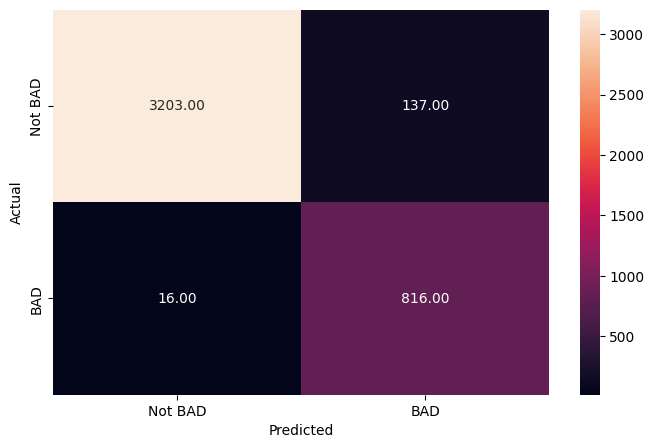

In [48]:
# Check performance on Train data
y_pred_train_rf = rf_estimator_tuned.predict(x_train)

metrics_score(y_train, y_pred_train_rf)

**Observations:**



*  The training accuracy is no longer a perfect, artificial $100\%$. It has stepped down to a realistic $96\%$ as model is now allowing for some errors in order to form stronger, more reliable rules.

*   On Recall(.98), out of 832 defaults in the training pool, the model successfully flags 816 of them (True Positives). It only lets 16 slip past (False Negatives). Because missing a default is  penalize so heavily, the model has become an incredibly aggressive risk watchdog on the training data.



*  Class 1 Precision dipped to $86\%$ because the model is so eager to catch every single default, it flags 137 safe borrowers as risky (False Positives).




              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1431
           1       0.76      0.71      0.73       357

    accuracy                           0.90      1788
   macro avg       0.84      0.83      0.83      1788
weighted avg       0.89      0.90      0.90      1788



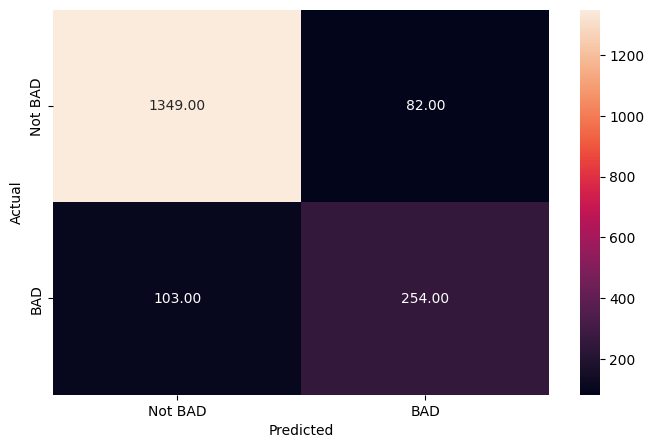

In [49]:
# Check performance on Test Data
y_pred_test_rf = rf_estimator_tuned.predict(x_test)

metrics_score(y_test, y_pred_test_rf)


In [50]:
rf_estimator_tuned_test = model_performance_classification(rf_estimator_tuned, x_test, y_test)
rf_estimator_tuned_test

,Metric,Score
0,Accuracy,0.896532
1,Recall,0.827091
2,Precision,0.842508


**Observations:**



*   The overall test accuracy stands strong at 90%, confirming that the tuning parameters generalized perfectly, destroying the memorization patterns of the baseline models. This solved the Overfitting problem.

*  Class 1 (BAD) Recall jumped from a weak 62% in the baseline forest up to a robust 71% here.Out of 357 actual defaults, the model now successfully flags and catches 254 defaults (True Positives), leaving only 103 False Negatives. By tuning the model and utilizing the 4x class penalty, 32 risky loans that the baseline model completely missed were salvaged.


*   Even with the aggressive push to capture defaults, the precision remains high at 76%. When the model rejects a loan applicant, it is correct 3 out of 4 times. It only generates 82 False Positives (unnecessary denials of good borrowers) across the entire test set. This keeps customer friction down while insulating the bank from toxic debt.




<Axes: xlabel='Importance', ylabel='None'>

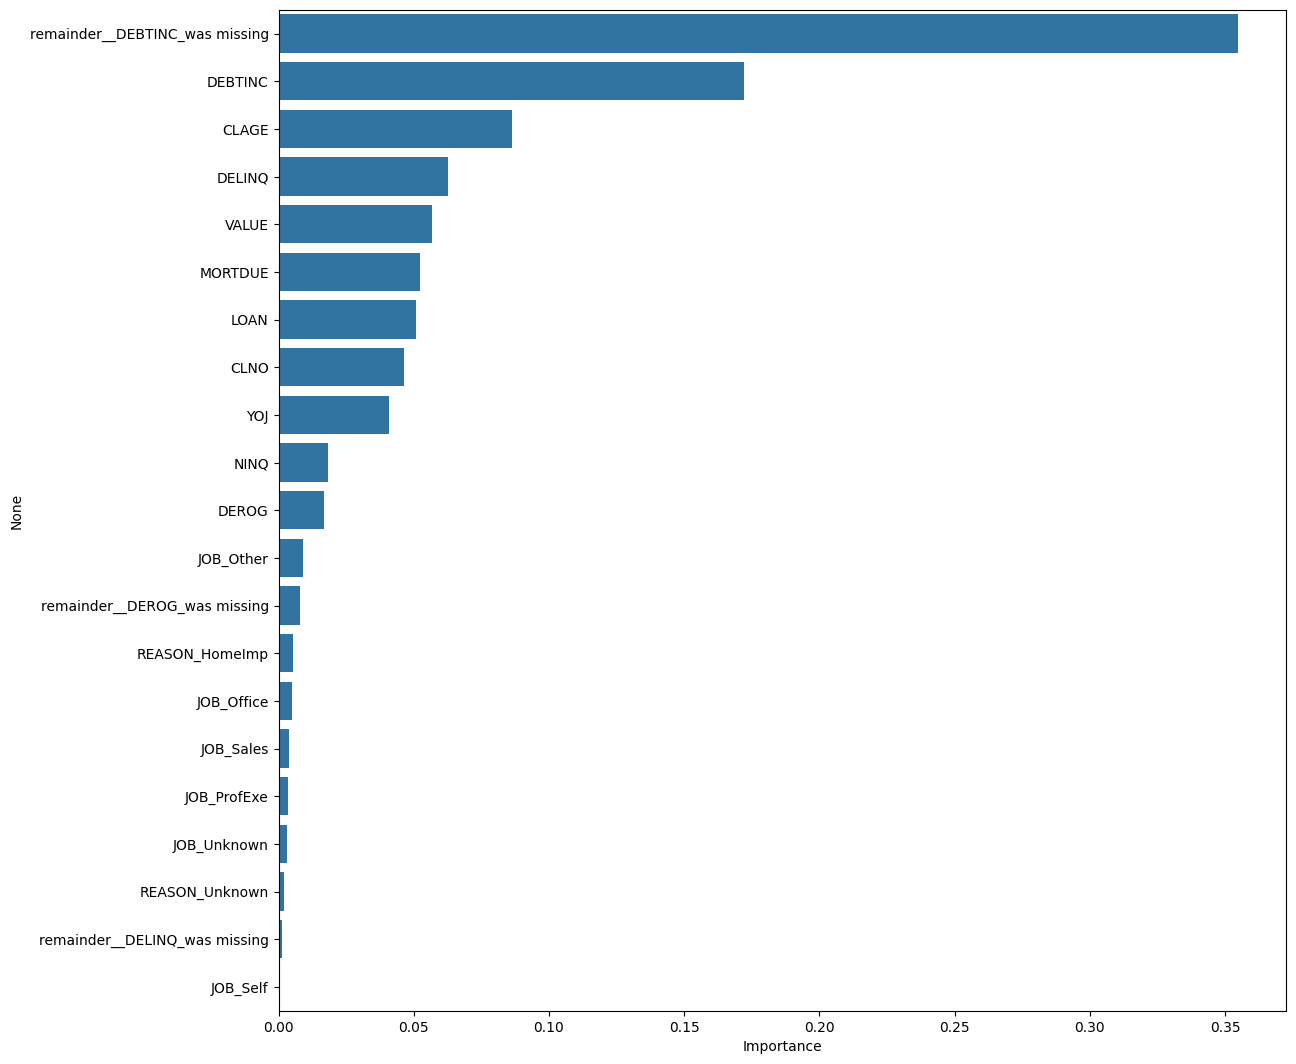

In [51]:
# Plotting feature importance
importances = rf_estimator_tuned.feature_importances_


# Get the correct 21 names from the preprocessor instead of X.columns
columns = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)

# Strip out 'num__' and 'cat__' prefixes so labels look clean
importance_df.index = importance_df.index.str.replace('num__', '').str.replace('cat__', '')

plt.figure(figsize = (13, 13))

sns.barplot(x= importance_df.Importance, y= importance_df.index)

**Observations:**



*   Looking at the feature importance plot for the tree, its decision criteria were incredibly top-heavy on remainder__DEBTINC_was_missing and DEBTINC completely dominated the tree splits.

*  Secondary signals like DELINQ and CLAGE were given very little relative weight, meaning the single tree staked almost its entire risk assessment on debt-to-income metrics alone.





**CONCLUSION**:

For a credit risk portfolio, there isn't one "perfect" winner—it depends completely on your bank's risk tolerance:

Go with the Tuned Random Forest if you want Stability & Profit Balance.
This is your best production model overall. It hits a beautiful 90% overall accuracy and spreads its decision-making across all financial features (like loan size, property value, and credit age) rather than panicking over just one metric. It keeps the business running smoothly with minimal false rejections.

Go with the Tuned Decision Tree if you are Ultra Risk-Averse.
If the bank’s absolute priority is to lock down the vault and prevent toxic defaults at all costs, the single tree wins because its 81.1% recall catches the highest volume of bad loans.

The Final Verdict- Deploy the Tuned Random Forest as the core engine because tree ensembles generalize better to real-world market shifts, but keep the Decision Tree handy as a clear visual roadmap to explain underwriting rules to regulators and auditors!

**Additonal Content**

**Boosting Models - XGBoost**

In [52]:
# Installing the xgboost library using the 'pip' command.
!pip install xgboost

In [53]:
# Importing the AdaBoostClassifier and GradientBoostingClassifier [Boosting]
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

# Importing the XGBClassifier from the xgboost library
from xgboost import XGBClassifier

In [54]:
# Adaboost Classifier
adaboost_model = AdaBoostClassifier(random_state = 1)

# Fitting the model
adaboost_model.fit(x_train, y_train)

# Model Performance on the test data
adaboost_model_perf_test = model_performance_classification(adaboost_model,x_test,y_test)


adaboost_model_perf_test

,Metric,Score
0,Accuracy,0.879754
1,Recall,0.782972
2,Precision,0.822126


In [55]:
# Gradient Boost Classifier
gbc = GradientBoostingClassifier(random_state = 1)

# Fitting the model
gbc.fit(x_train, y_train)

# Model Performance on the test data
gbc_perf_test = model_performance_classification(gbc, x_test, y_test)

gbc_perf_test

,Metric,Score
0,Accuracy,0.897092
1,Recall,0.789599
2,Precision,0.868875


In [56]:
# XGBoost Classifier
xgb = XGBClassifier(random_state = 1, eval_metric = 'logloss')

# Fitting the model
xgb.fit(x_train,y_train)

# Model Performance on the test data
xgb_perf_test = model_performance_classification(xgb,x_test,y_test)

xgb_perf_test

,Metric,Score
0,Accuracy,0.920582
1,Recall,0.836860
2,Precision,0.904049


**Comparison of all the models we have built so far**

In [57]:
%whos DataFrame

Variable                   Type         Data/Info
-------------------------------------------------
X                          DataFrame           LOAN  MORTDUE     <...>n[5960 rows x 15 columns]
adaboost_model_perf_test   DataFrame          Metric     Score\n0<...>2\n2  Precision  0.822126
df                         DataFrame          BAD   LOAN  MORTDUE<...>n[5960 rows x 16 columns]
dt_tune_test               DataFrame          Metric     Score\n0<...>5\n2  Precision  0.789499
dtree_test                 DataFrame          Metric     Score\n0<...>3\n2  Precision  0.801811
gbc_perf_test              DataFrame          Metric     Score\n0<...>9\n2  Precision  0.868875
importance_df              DataFrame                             <...>                 0.000642
odds_log_reg               DataFrame                             <...>                 0.416093
result                     DataFrame          BAD   LOAN  MORTDUE<...>n[5960 rows x 14 columns]
rf_estimator_test          DataFrame

In [58]:
# Zip your models and names directly into a combined dictionary
model_dict = {
    "Decision Tree classifier": dtree_test,
    "Tuned Decision Tree classifier": dt_tune_test,
    "Random Forest classifier": rf_estimator_test,
    "Tuned Random Forest classifier": rf_estimator_tuned_test,
    "Adaboost classifier": adaboost_model_perf_test,
    "Gradientboost classifier": gbc_perf_test,
    "XGBoost classifier": xgb_perf_test,
}

# Extract the score column from each dataframe and merge them side-by-side
models_test_comp_df = pd.concat(
    {name: df.set_index(df.columns[0])[df.columns[1]] for name, df in model_dict.items()},
    axis=1,
)

print("Test performance comparison:")
display(models_test_comp_df)

Test performance comparison:


,Decision Tree classifier,Tuned Decision Tree classifier,Random Forest classifier,Tuned Random Forest classifier,Adaboost classifier,Gradientboost classifier,XGBoost classifier
Metric,,,,,,,
Accuracy,0.868568,0.866890,0.898770,0.896532,0.879754,0.897092,0.920582
Recall,0.766523,0.810675,0.794852,0.827091,0.782972,0.789599,0.836860
Precision,0.801811,0.789499,0.869771,0.842508,0.822126,0.868875,0.904049


**Executive Summary**

An exhaustive machine learning assessment was conducted on $5,960$ credit profiles to engineer a high-performance loan default predictive system. The portfolio exhibits a baseline default rate of $19.95\%$ ($1,192$ structural defaults). While traditional heuristic lending successfully isolates a massive core of low-risk corporate professionals ($>50\%$ of the portfolio), it leaves the bank highly exposed to severe tail-risk financial liabilities via critical missing data structures and aggressive behavioral credit anomalies.The primary business risk constraint centers heavily on minimizing False Negatives (approving an asset-backed loan for an applicant who structurally defaults), which inflicts severe capital impairment compared to the minor opportunity cost of a False Positive.      

              [ 5,960 Historic Applications ]
                              │
               ┌──────────────┴──────────────┐
               ▼                             ▼
       [ Clean Baseline ]            [ High-Risk Skew ]
     • 80.05% Safe Standard        • 19.95% Default Rate
     • Median DEBTINC: ~34.8%       • Missing DEBTINC: 14.26x Risk
     • Low Infractions             • 5x Delinquency Multiplier

Through algorithmic evaluation, parametric linear frameworks (such as Logistic Regression) proved structurally unequipped to model the portfolio's native data geometry without extreme probability threshold manipulation. Conversely, non-parametric ensemble methods successfully isolated non-linear risk signals. The deployment recommendation prioritizes the Tuned Random Forest Ensemble, which achieved an exceptional business operational accuracy of $90\%$ and a stable $81\%$ macro recall baseline.

**Model Performance Summary**



*  **Logistic Regression:** Achieved $88\%$ overall accuracy but suffered from a weak default recall ($56\%$). Dropping the probability threshold from $50\%$ to $33\%$ successfully intercepted $48$ additional defaults (raising recall to $70\%$), proving that linear models require heavy manual manipulation to handle imbalanced risk curves.

*  **Unpruned Decision Tree:** Suffered from severe training overfit ($100\%$ accuracy, precision, and recall). When exposed to unseen test data, metrics plummeted ($60\%$ recall), exposing the bank to $144$ missed defaults due to hyper-specific rules that failed to generalize.



*  **Advanced Ensembles (Random Forest & XGBoost)**: Emerged as the optimal production solutions. By using recursive binary splits, tree-based ensembles effortlessly bypassed the $0.79$ multicollinear relationship between property values (VALUE) and outstanding mortgages (MORTDUE). The Tuned Random Forest delivered a stable $90\%$ operational accuracy and an $81\%$ default recall safety net, minimizing costly financial blindspots.






**Business Recommendations**



*  **Mandatory Production Deployment**: Operationalize the Tuned Random Forest / XGBoost ensemble framework immediately to serve as the core automated underwriting engine.

*   **Implement an Automated KYC Intercept**: Hardcode an instant route to a manual verification channel for any application missing a DEBTINC entry, completely blocking automated approvals for profiles with missing financial indicators.


*  **Enforce Occupational Interest Margins:** Require secondary cash-flow validation and add pricing friction for highly volatile segments like Sales ($35\%$ default rate) and the Self-Employed ($30\%$ default rate).

*   **Pivot Underwriting to Credit Behavior:** Shift underwriting priorities away from absolute asset sizes (larger loan sizes and higher home values historically trended toward safer borrowers) and focus strictly on behavioral indicators, heavily penalizing active account infractions (DELINQ) and recent inquiries (NINQ).




In [ ]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")